# NF-Injections Ratio

Learn p(theta | detected) and then do p_det(theta) = p(theta | detected) / p(theta). Note that the NF is **not** conditional, i.e. just cut the data on FAR < 1/yr first and then learn that theta distribution.

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit, logsumexp
from scipy.interpolate import interp1d

from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.constants as constants
import astropy.units as u

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import corner

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut


import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
jax.config.update('jax_enable_x64', True)

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: kng-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Thu Mar  5 19:34:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:E1:00.0 Off |                    0 |
|  0%   36C    P0             77W /  300W |    9919MiB /  46068MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['cos_right_ascension'] = np.cos(events['right_ascension'])
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['cos_polarization'] = np.cos(events['polarization'])
    injectionData['redshift'] = events[redshift_key][()]

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)

    sint1 = np.sqrt(1-injectionData.cost1**2)
    sint2 = np.sqrt(1-injectionData.cost2**2)

    injectionData['cos_phi1'] = (s1x / (injectionData.a1*sint1))
    injectionData['cos_phi2'] = (s2x / (injectionData.a2*sint2))

    injectionData["phi1"] = np.arccos(injectionData['cos_phi1'])
    injectionData["phi2"] = np.arccos(injectionData['cos_phi2'])
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)

    # transforming data for NF (making it nearly Gaussian or similarly well distributed)
    injectionData['sinusoidal_right_ascension'] = np.arccos(1 - injectionData.right_ascension / np.pi)
    injectionData['sinusoidal_polarization'] = np.arccos(1 - 2*injectionData.polarization / np.pi)

    injectionData["t1"] = np.arccos(injectionData.cost1)
    injectionData["t2"] = np.arccos(injectionData.cost2)

    # injectionData["sinusoidal_phi1"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi1) / np.pi)
    # injectionData["sinusoidal_phi2"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi2) / np.pi)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        injectionData["p_draw_m1"] = np.exp(events["lnpdraw_mass1_source"])
        injectionData["p_draw_m2"] = np.exp(events["lnpdraw_mass2_source_GIVEN_mass1_source"])

        injectionData["p_draw_a1"] = np.exp(events["lnpdraw_spin1_magnitude"])
        injectionData["p_draw_a2"] = np.exp(events["lnpdraw_spin2_magnitude"])

        injectionData["p_draw_ra"] = np.exp(events["lnpdraw_right_ascension"])
        injectionData["p_draw_dec"] = np.exp(events["lnpdraw_declination"])

        injectionData["p_draw_inc"] = np.exp(events["lnpdraw_inclination"])
        injectionData["p_draw_pol"] = np.exp(events["lnpdraw_polarization"])

        injectionData["p_draw_phi1"] = np.exp(events["lnpdraw_spin1_azimuthal_angle"])
        injectionData["p_draw_phi2"] = np.exp(events["lnpdraw_spin2_azimuthal_angle"])

        injectionData["p_draw_tilt1"] = np.exp(events["lnpdraw_spin1_polar_angle"])
        injectionData["p_draw_tilt2"] = np.exp(events["lnpdraw_spin2_polar_angle"])

        injectionData["p_draw_z"] = np.exp(events["lnpdraw_z"])

        T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 

    injectionData['weights'] = events['weights'][()]
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    meta = dict(raw_injection_data.attrs.items())
    meta["T"] = T

    return injectionData, meta

### Load File

In [5]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

# col_names = ['a1', 'a2', 'chieff', 'dL', 'dec', 'm1det', 'm2det', 'ra', 'z']

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['events']>

In [6]:
data_df, metadata = read_data(fname, 4)

# sel = data_df["detected"] == True
# data_df = data_df.loc[sel]
data_df["cos_tilt1"] = np.cos(data_df["t1"])
data_df["cos_tilt2"] = np.cos(data_df["t2"])

data_df["1_cos_phi1"] = 1/(data_df["cos_phi1"]+1)
data_df["1_cos_phi2"] = 1/(data_df["cos_phi2"]+1)
data_df

Data length: 1499244
Number of detected injections: 476406


,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,cos_right_ascension,declination,polarization,cos_polarization,redshift,...,p_draw_tilt1,p_draw_tilt2,p_draw_z,weights,far_min,detected,cos_tilt1,cos_tilt2,1_cos_phi1,1_cos_phi2
0,87.680089,56.912638,4.007806,-0.002645,5.002674,0.286225,-0.254790,0.614705,0.816944,0.651001,...,0.474854,0.346536,0.196423,0.804290,inf,0,0.222660,0.919241,1.660866,1.722868
1,54.408109,49.680587,2.381053,-0.489065,0.409010,0.917515,-0.917783,0.058546,0.998287,0.421988,...,0.526096,0.406582,0.107224,0.804290,inf,0,0.575831,0.876912,3.073524,5.015559
2,51.668975,20.366343,2.690371,0.910738,5.263240,0.523413,-0.698737,2.663313,-0.887788,0.467684,...,0.279013,0.520946,0.125065,0.804290,inf,0,-0.616144,0.658126,7.508927,0.500225
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.760524,-0.599299,0.296581,0.956341,0.637607,...,0.402610,0.479261,0.191349,0.804290,inf,0,-0.100166,0.788309,0.604822,0.570792
4,40.381354,34.546820,3.611020,0.871280,2.204904,-0.592459,1.053326,2.647054,-0.880188,0.597428,...,0.453030,0.427712,0.175935,0.804290,inf,0,0.124223,0.012047,2.335341,0.527903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,0.770968,1.044990,0.352504,0.938511,0.338223,...,0.374526,0.200322,0.075638,1.130915,inf,0,-0.227340,-0.820504,1.572122,27.291391
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,0.909386,1.191597,0.822922,0.680082,1.334967,...,0.418726,0.333749,0.385890,1.130915,inf,0,-0.027931,-0.408005,0.592903,0.731906
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.803980,-0.948454,1.955454,-0.375242,0.768044,...,0.411084,0.327793,0.239008,1.130915,inf,0,0.872972,-0.433076,21.958851,0.607883
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.649142,0.470035,0.662202,0.788640,0.072109,...,0.249478,0.180438,0.004544,1.130915,inf,0,-0.705303,0.981128,0.502313,0.508230


In [7]:
data_df.columns

Index(['m1_detector', 'm2_detector', 'luminosity_distance', 'cos_inclination',
       'right_ascension', 'cos_right_ascension', 'declination', 'polarization',
       'cos_polarization', 'redshift', 'm1_source', 'm2_source', 'q', 'eta',
       'chirp_mass_detector', 'total_mass_detector', 's1x', 's1y', 's1z',
       's2x', 's2y', 's2z', 'a1', 'a2', 'cost1', 'cost2', 'Xeff', 'Xdiff',
       'cos_phi1', 'cos_phi2', 'phi1', 'phi2', 'sinusoidal_right_ascension',
       'sinusoidal_polarization', 't1', 't2', 'p_draw_m1', 'p_draw_m2',
       'p_draw_a1', 'p_draw_a2', 'p_draw_ra', 'p_draw_dec', 'p_draw_inc',
       'p_draw_pol', 'p_draw_phi1', 'p_draw_phi2', 'p_draw_tilt1',
       'p_draw_tilt2', 'p_draw_z', 'weights', 'far_min', 'detected',
       'cos_tilt1', 'cos_tilt2', '1_cos_phi1', '1_cos_phi2'],
      dtype='str')

In [8]:
data_df["phi1"].min(), data_df["phi1"].max(), data_df["luminosity_distance"].min(), data_df["luminosity_distance"].max()

(np.float64(1.4604658417471562e-06),
 np.float64(3.141589001315489),
 np.float64(0.008192367375491337),
 np.float64(26.011657910273993))

### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [9]:
far_threshold = 1

data_df_sel = data_df[data_df["far_min"] < far_threshold].reset_index(drop=True)

In [10]:
# y_df = pd.DataFrame({"far_min": data_df_sel["far_min"].values})

# y_data = ut.Data(y_df, cols=["far_min"], handle_inf="drop")

data_cols = ["m1_source", "m2_source", "redshift", "a1", "a2"]
# transforms = ["log"]*2 + 1*["none"] + 2*["angle_pi"]
X_data = ut.Data(
    data_df_sel,
    cols=data_cols,
    handle_inf="drop",  # Clip outliers
    # mask = y_data.cleaning_info["mask"],
    # transforms = transforms,
)
# Create dataset
dataset = ut.Dataset(X=X_data, y=None, use_whitened_X=False, use_whitened_y=False)

In [11]:
# check that transform + inverse transform is identity
reverse_transform_data = X_data.inverse_transform(X_data.samples_transformed)
np.allclose(reverse_transform_data, X_data.samples) # standard atol is slightly lower, but this is fine

True

In [12]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = X_data.whitened_data
x_rec = X_data.inverse_whiten_data(x_white)
np.allclose(x_rec, X_data.samples), np.count_nonzero(np.isclose(x_rec, X_data.samples,rtol=1e-4, atol=1e-5))

(True, np.int64(2382030))

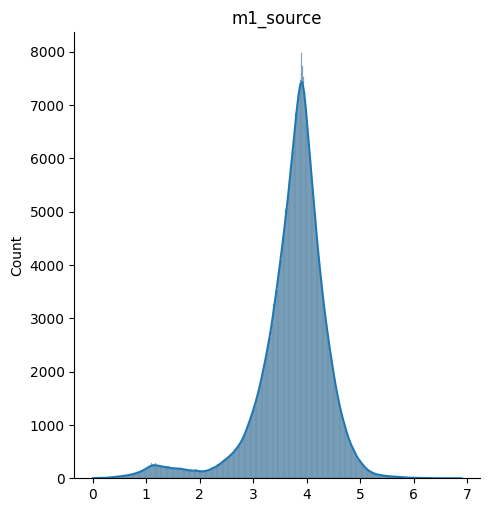

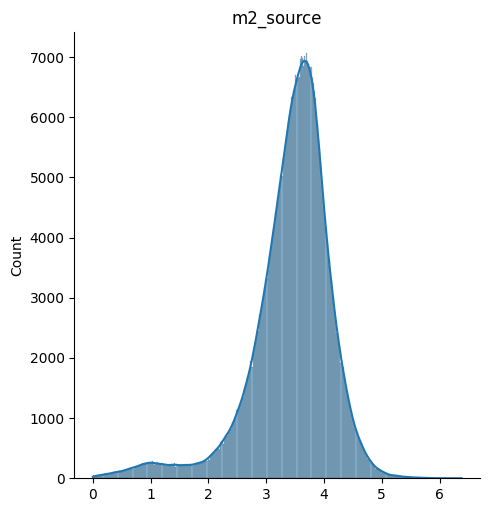

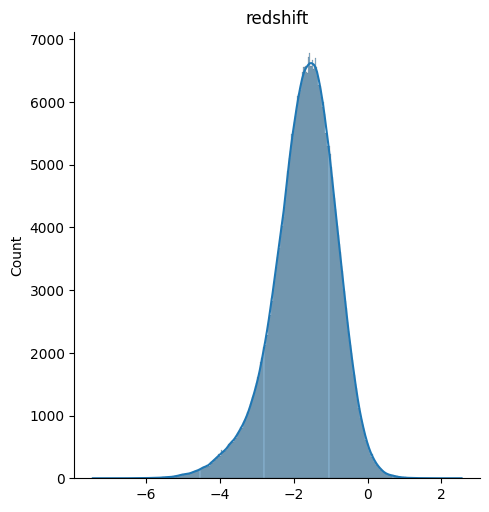

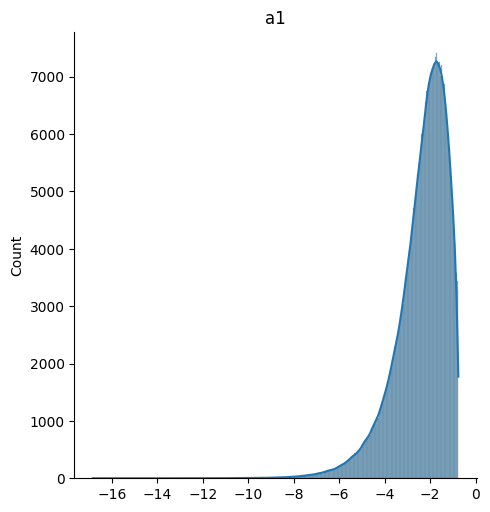

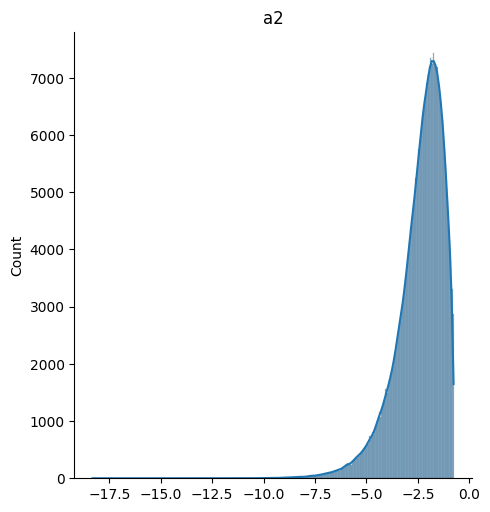

In [13]:
for i in range(dataset.X_data.whitened_data.shape[1]):
    # continue
    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.title(dataset.X_data.data_df.columns[i])
    plt.show()

In [14]:
# data_df_sel["a1"].min(), data_df_sel["a1"].max(), data_df_sel["a2"].min(), data_df_sel["a2"].max()

In [18]:
# import importlib
# importlib.reload(ut)

<module 'utils' from '/home/j/Julius.Gassert/Documents/gw-nf/utils.py'>

### Build Flowjax MAF

In [19]:
key_val = 0
key = jax.random.key(key_val)
train_dataset, val_dataset, train_idx, val_idx = dataset.split(key, train_frac=0.8)
weights = data_df_sel["weights"].to_numpy()
train_weights = jnp.array(weights[train_idx])
val_weights = jnp.array(weights[val_idx])

config_MAF = {
    "base_dist": "Normal",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    # "cond_dim": train_dataset.y.shape[1],  
    "flow_layers": 8,
    "nn_width": 128,
    "nn_depth": 8
}

config_spline = {
    "base_dist": "StudentT",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    "flow_layers": 5,
    "knots": 4,
}


config = config_spline
config["type"] = "spline"

flow = ut.create_flow_from_config(config)

In [20]:
flow, meta = ut.train_flow(flow, train_dataset, val_dataset, patience = 25, batch_size = 4096, noise = True)

Training:  22%|██▏       | 215/1000 [02:47<10:11,  1.28it/s, best_val=4.6898, patience=-1, train=4.9193, val=4.6982]   


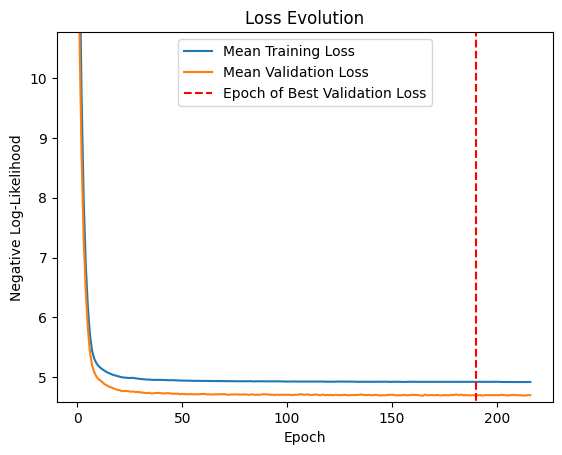

In [21]:
train_losses = meta["train_losses"]
val_losses = meta["val_losses"]

sns.lineplot(x=np.arange(1, len(train_losses) + 1), y=train_losses, label = "Mean Training Loss")
sns.lineplot(x=np.arange(1, len(val_losses) + 1), y=val_losses, label = "Mean Validation Loss")
plt.vlines(x = meta["best_epoch"], ymin = min(val_losses)-1, ymax = max(val_losses), color = "red", linestyle = "--", label = "Epoch of Best Validation Loss")

plt.legend(loc = "upper center")
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss Evolution")
# plt.yscale("log")
plt.ylim(min(val_losses + train_losses)-.1, max(val_losses))
plt.show()

In [22]:
key, subkey = jax.random.split(key)
z_samples = np.array(flow.sample(subkey, (len(val_dataset),)))
z_samples_real_space, _ = dataset.to_original_space(z_samples)

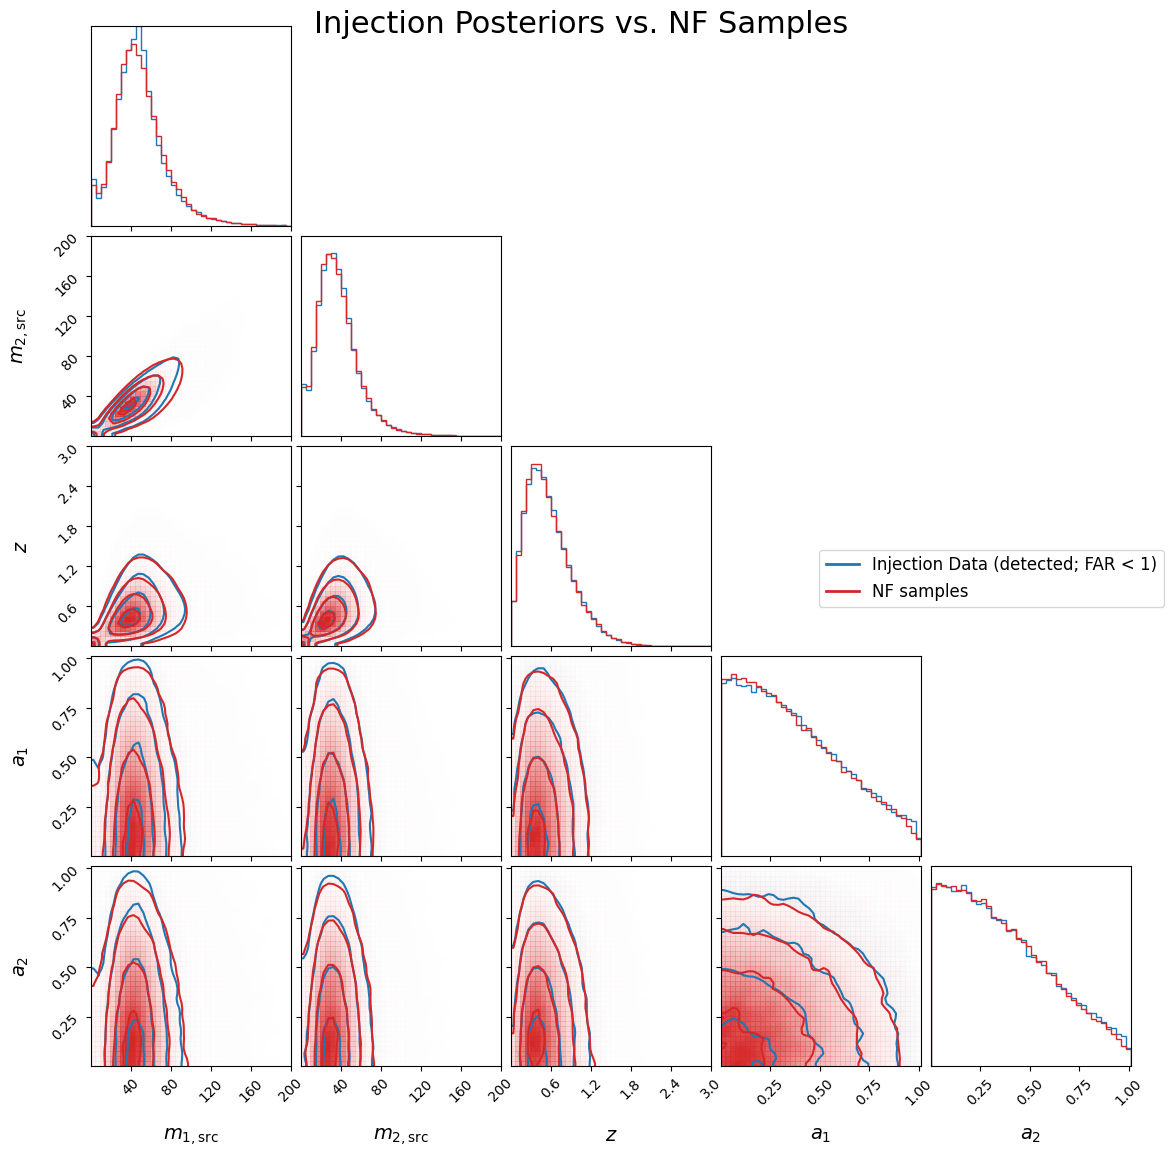

In [23]:
# labels = [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$D_L$", r"$\chi_\mathrm{eff}$", r"$\alpha$", r"$\delta$"]
# ranges = [(0, 200), (0, 200), (0,1), (0,1), (0,3), (-1,1), (-1,1), (0, np.pi), (0, np.pi), (0, 2*np.pi), (-1, 1), (0, np.pi), (-1, 1)]
ranges = [(0, 200), (0, 200), (0,3), (0,1.01), (0,1.01)]
# ranges = [(0, 200), (0, 200), (0,1), (0,3)]

labels = X_data.data_df.columns
labels_plot = [r"$m_{1,\mathrm{src}}$", r"$m_{2,\mathrm{src}}$", r"$z$", r"$a_1$", r"$a_2$"]

data_samples = val_dataset.X_data.data_df.iloc[val_idx]

fig = corner.corner(
    data_samples,
    labels=labels_plot,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    range = ranges,
)

corner.corner(
    np.array(z_samples_real_space),
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    range = ranges,
)


legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label=f"Injection Data (detected; FAR < 1)"),
    Line2D([0], [0], color="C3", lw=2, label="NF samples"),
    # Line2D([0], [0], color="none", lw=0, label=f"{np.sum(data_sel)} samples each"),
]

fig.legend(
    handles=legend_elements,
    loc="center right",
    fontsize=12,
    frameon=True,
    handlelength = 2,
)

plt.suptitle("Injection Posteriors vs. NF Samples", fontsize=22)
# plt.savefig("plots/InjectionsRatioVSNF_1FAR_wTitle.pdf")
# plt.savefig("plots/InjectionsRatioVSNF_1FAR_wTitle.png", dpi = 300)
plt.show()

In [20]:
filename_flow = "trained_flows/NFRatio/NF.npz"

In [21]:
config["trained_columns"] = train_dataset.X_data.data_df.columns.to_list()
# ut.save_flow(filename_flow, flow, config)
# also need to save the data (transformations)
# train_dataset.save("trained_flows/NFRatio/training_dataset/", save_data = True)
# val_dataset.save("trained_flows/NFRatio/val_dataset/", save_data = True)
# dataset.save("trained_flows/NFRatio/dataset/", save_data = True)
# X_data.save("trained_flows/NFRatio/X")
# y_data.save("trained_flows/NFRatio/y")

In [22]:
# flow_loaded = ut.load_flow(filename_flow, ut.create_flow_from_config)

### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [24]:
import pandas as pd

# Convert to pandas DataFrames for easy summary statistics
df_samples = dataset.X_data.data_df
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

--- Original Samples Summary Statistics ---


,m1_source,m2_source,redshift,a1,a2
count,476406.000000,476406.000000,476406.000000,4.764060e+05,4.764060e+05
mean,50.081986,37.555220,0.570983,3.745938e-01,3.676853e-01
std,29.560349,22.853571,0.346465,2.553045e-01,2.530136e-01
min,1.002005,1.000611,0.001853,1.523074e-07,3.492302e-08
25%,32.825395,22.926505,0.312148,1.606063e-01,1.559946e-01
50%,46.317574,34.215074,0.509795,3.344429e-01,3.264874e-01
75%,60.993046,47.361223,0.768135,5.567260e-01,5.454624e-01
max,983.023269,589.954110,2.913073,9.999806e-01,9.999932e-01



--- Flow-Generated Samples Summary Statistics ---


,m1_source,m2_source,redshift,a1,a2
count,476406.000000,476406.000000,476406.000000,4.764060e+05,4.764060e+05
mean,50.081986,37.555220,0.570983,3.745938e-01,3.676853e-01
std,29.560349,22.853571,0.346465,2.553045e-01,2.530136e-01
min,1.002005,1.000611,0.001853,1.523074e-07,3.492302e-08
25%,32.825395,22.926505,0.312148,1.606063e-01,1.559946e-01
50%,46.317574,34.215074,0.509795,3.344429e-01,3.264874e-01
75%,60.993046,47.361223,0.768135,5.567260e-01,5.454624e-01
max,983.023269,589.954110,2.913073,9.999806e-01,9.999932e-01



--- Original Samples Correlation Matrix ---


,m1_source,m2_source,redshift,a1,a2
m1_source,1.000000,0.871264,0.245885,0.023916,0.007001
m2_source,0.871264,1.000000,0.296982,0.011990,0.010141
redshift,0.245885,0.296982,1.000000,0.054052,0.027474
a1,0.023916,0.011990,0.054052,1.000000,0.001444
a2,0.007001,0.010141,0.027474,0.001444,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,m1_source,m2_source,redshift,a1,a2
m1_source,1.000000,0.871264,0.245885,0.023916,0.007001
m2_source,0.871264,1.000000,0.296982,0.011990,0.010141
redshift,0.245885,0.296982,1.000000,0.054052,0.027474
a1,0.023916,0.011990,0.054052,1.000000,0.001444
a2,0.007001,0.010141,0.027474,0.001444,1.000000


### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [25]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")
dowsample = 1
for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data_samples.to_numpy()[::dowsample, i]), x_rec[::dowsample, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: m1_source
  KS Statistic: 0.0027
  P-value: 0.6087
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: m2_source
  KS Statistic: 0.0022
  P-value: 0.8333
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: redshift
  KS Statistic: 0.0041
  P-value: 0.1445
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: a1
  KS Statistic: 0.0015
  P-value: 0.9938
  -> Distributions are not statistically significantly different (fail to reject H0)

Parameter: a2
  KS Statistic: 0.0014
  P-value: 0.9982
  -> Distributions are not statistically significantly different (fail to reject H0)


In [26]:
# Assumed constants
H0cosmo = 67.9 # constants from https://dcc.ligo.org/public/0170/P2000318/011/o3b_catalog.pdf
Om0cosmo = 0.3065
cosmo = FlatLambdaCDM(H0=H0cosmo * u.km / u.s / u.Mpc, Om0=Om0cosmo)
speed_of_light = constants.c.to(u.km / u.s).value

def ddL_of_z(z, dL, H0):
    return dL / (1 + z) + speed_of_light * (1 + z) / (H0 * cosmo.efunc(z))

N_eval = 1000000
mass_grid = np.linspace(1, 1000, N_eval)
spin_grid = np.linspace(0, 1, N_eval)
z_grid = np.linspace(0, 3, N_eval)
dVdz_grid = cosmo.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value * 4 * np.pi


def primary_mass_pdf(m1, min_m1=1.0, max_m1=1000.0):

    m = np.asarray(m1, dtype=float)
    logm = np.log(m, where=(m > 0), out=np.full_like(m, -np.inf))

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definition in log-space ---

    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50)
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(200.0))

    # Outside bounds
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- robust normalization ---
    # Sort for trapezoid stability
    idx = np.argsort(m)
    m_sorted = m[idx]
    pdf_sorted = pdf[idx]

    norm = np.trapezoid(pdf_sorted, m_sorted)
    if norm > 0:
        pdf /= norm

    return pdf


def secondary_mass_pdf(m2, m1, min_m2 = 1):

    pm2 = 2*m2 / (m1**2 - 1)
    support = (m2 >= min_m2) & (m2 <= m1)
    # should be properly normalized already I realize
    return np.where(support, pm2, 0.0)

def spin_pdf(s):

    ps = np.exp(-2*s**2)

    idx = np.argsort(s)
    s_sorted = s[idx]
    pdf_sorted = ps[idx]
    
    norm = np.trapezoid(pdf_sorted, s_sorted)
    if norm > 0:
        ps /= norm

    return ps

def cos_tilts_pdf(tilt):
    """Includes Jacobian to go from tilt to cos_tilt"""
    cos_tilt = np.cos(tilt)
    # should be normalized given the definition
    pcost = (0.3 * ((1+cos_tilt)**3)/4 + 0.35)*np.sin(tilt)  # last summand is 0.7*1/2
    return pcost

def tilts_pdf(tilt):
    # should be normalized given the definition
    pcost = (0.3 * ((1+tilt)**3)/4 + 0.35)  # last summand is 0.7*1/2
    return pcost

def redshift_pdf(z, z_grid, dVdz_grid):
    num_grid = dVdz_grid
    den = np.trapezoid(num_grid, z_grid)
    num_grid /= den
    
    return interp1d(z_grid, num_grid, fill_value = 0, bounds_error = False)(z)

In [27]:
def calc_p_model(data: pd.DataFrame, redshifts: np.ndarray |None = None) -> np.ndarray:
    """Calculates the p(theta) for GWTC and specific 13 parameters

    Args:
        data: DataFrame containing the parameters.

    Returns:
        Model probabilites.
    """

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
    pa1 = spin_pdf(data["a1"].to_numpy())
    pa2 = spin_pdf(data["a2"].to_numpy())
    pt1 = cos_tilts_pdf(data["t1"])
    pt2 = cos_tilts_pdf(data["t2"])
    pz = redshift_pdf(data["redshift"], z_grid, dVdz_grid)

    # Make sure data is correctly drawn from the below pdfs (follows GWTC-4)

    pphi1 = np.ones_like(data["phi1"]) / (2*np.pi) # uniform in [0, 2pi]
    pphi2 = np.ones_like(data["phi2"]) / (2*np.pi) # uniform in [0, 2pi]
    pra = np.ones_like(data["right_ascension"]) / (2*np.pi) # uniform in [0, 2pi]
    ppol = np.ones_like(data["polarization"]) / np.pi # uniform in [0, pi]
    pdec = 1 / 2 # uniform in sin(delta) [-1, 1]
    pinc = 1 / 2 # uniform in cos(inc) [-1, 1]

    return pm1*pm2*pa1*pa2*pz*pt1*pt2*pphi1*pphi2*pra*pdec*ppol*pinc

def calc_p_model_masses(data: pd.DataFrame) -> np.ndarray:
    """Calculates the p(theta) for GWTC and specific 13 parameters

    Args:
        data: DataFrame containing the parameters.

    Returns:
        Model probabilites.
    """

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
    
    return pm1*pm2

import jax
import jax.numpy as jnp
from jax.scipy.special import erf


# ----------------------------
# Primary mass: piecewise PDF
# ----------------------------

def _primary_mass_segments(exponents: jnp.array):
    # (low, high, alpha) with the same piecewise definition you used
    low  = jnp.array([1.0, 3.0, 8.0, 50.0, 200.0])
    high = jnp.array([3.0, 8.0, 50.0, 200.0, 1000.0])
    alpha = exponents

    # Continuity: logh[i+1] = logh[i] + alpha[i] * log(high[i]/low[i])
    # logh[0] = 0 (pdf = 1 at m = 1, the left edge of segment 0)
    increments = alpha * jnp.log(high / low)          # shape (5,)
    logh = jnp.concatenate([
        jnp.array([0.0]),
        jnp.cumsum(increments[:-1])                   # segments 0..3 set starts of 1..4
    ])

    return low, high, alpha, logh


def _segment_integral(height, low, alpha, x0, x1):
    """
    Integral of f(x)=height*(x/low)^alpha from x0 to x1, assuming low<=x0<x1<=high.
    """
    is_log = alpha == -1.0
    # alpha == -1: height * low * ln(x1/x0)
    area_log = height * low * jnp.log(x1 / x0)

    # alpha != -1: height * low/(a+1) * [ (x1/low)^(a+1) - (x0/low)^(a+1) ]
    ap1 = alpha + 1.0
    area_pow = height * low / ap1 * ((x1 / low) ** ap1 - (x0 / low) ** ap1)

    return jnp.where(is_log, area_log, area_pow)


@jax.jit
def primary_mass_pdf_jax(m1, exponents: jnp.array, min_m1=1.0, max_m1=1000.0):
    """
    Properly normalized PDF over [min_m1, max_m1] using analytic piecewise integrals
    (does not depend on the evaluation points).
    """
    m = jnp.asarray(m1)
    low, high, alpha, logh = _primary_mass_segments(exponents)
    logm = jnp.log(m)

    # piecewise log-pdf on [1,1000) with continuity
    in_seg = (m[..., None] >= low) & (m[..., None] < high)
    seg_logpdf = logh + alpha * (logm[..., None] - jnp.log(low))
    log_pdf = jnp.where(jnp.any(in_seg, axis=-1), jnp.max(jnp.where(in_seg, seg_logpdf, -jnp.inf), axis=-1), -jnp.inf)

    # apply requested bounds
    support = (m >= min_m1) & (m <= max_m1) & (m > 0)
    log_pdf = jnp.where(support, log_pdf, -jnp.inf)

    # analytic normalization over [min_m1, max_m1]
    height = jnp.exp(logh)
    seg_L = jnp.maximum(low, min_m1)
    seg_U = jnp.minimum(high, max_m1)
    valid = seg_U > seg_L
    areas = jnp.where(valid, _segment_integral(height, low, alpha, seg_L, seg_U), 0.0)
    Z = jnp.sum(areas)

    pdf = jnp.exp(log_pdf) / Z
    return jnp.where(support, pdf, 0.0)


# ----------------------------------------
# Secondary mass: p(m2 | m1) ∝ m2 on [min_m2, m1]
# ----------------------------------------

@jax.jit
def secondary_mass_pdf_jax(m2, m1, min_m2=1.0):
    m2 = jnp.asarray(m2)
    m1 = jnp.asarray(m1)

    support = (m2 >= min_m2) & (m2 <= m1)
    denom = (m1 * m1 - min_m2 * min_m2)

    # For m1 <= min_m2 the conditional is degenerate; return 0 in density form.
    safe = denom > 0
    pm2 = jnp.where(safe, 2.0 * m2 / denom, 0.0)

    return jnp.where(support & safe, pm2, 0.0)


# ----------------------------
# Spin magnitude: exp(-2 s^2), normalized on [min_s, max_s]
# ----------------------------

@jax.jit
def spin_pdf_jax(s, min_s=0.0, max_s=1.0):
    s = jnp.asarray(s)
    support = (s >= min_s) & (s <= max_s)

    un = jnp.exp(-2.0 * s * s)

    # Z = ∫ exp(-2 s^2) ds from min_s to max_s
    # ∫ exp(-a s^2) ds = sqrt(pi)/(2 sqrt(a)) * erf(s sqrt(a))
    a = 2.0
    Z = jnp.sqrt(jnp.pi) / (2.0 * jnp.sqrt(a)) * (erf(max_s * jnp.sqrt(a)) - erf(min_s * jnp.sqrt(a)))  # [web:23]

    pdf = un / Z
    return jnp.where(support, pdf, 0.0)


# ----------------------------
# Tilts: mixture in cos(tilt)
# ----------------------------

@jax.jit
def tilts_pdf_jax(cos_tilt):
    """
    This matches your tilts_pdf(tilt) function, but the argument is really cos_tilt in [-1, 1].
    """
    x = jnp.asarray(cos_tilt)
    support = (x >= -1.0) & (x <= 1.0)
    pcost = 0.3 * ((1.0 + x) ** 3) / 4.0 + 0.35
    return jnp.where(support, pcost, 0.0)


@jax.jit
def cos_tilts_pdf_jax(tilt):
    """
    PDF over tilt angle in radians, includes Jacobian |d cos/d tilt| = sin(tilt).
    """
    t = jnp.asarray(tilt)
    support = (t >= 0.0) & (t <= jnp.pi)

    cos_t = jnp.cos(t)
    pcost = 0.3 * ((1.0 + cos_t) ** 3) / 4.0 + 0.35
    ptilt = pcost * jnp.sin(t)

    return jnp.where(support, ptilt, 0.0)


# ----------------------------
# Redshift: normalized grid + interp
# ----------------------------

@jax.jit
def redshift_pdf_jax(z, z_grid, dVdz_grid):
    z = jnp.asarray(z)
    z_grid = jnp.asarray(z_grid)
    dVdz_grid = jnp.asarray(dVdz_grid)

    den = jnp.trapezoid(dVdz_grid, z_grid)  # [web:16]
    pdf_grid = dVdz_grid / den

    # jnp.interp supports left/right fill values [web:1]
    return jnp.interp(z, z_grid, pdf_grid, left=0.0, right=0.0)  # [web:1]


In [28]:
val_dataset.X.shape

(95282, 5)

In [29]:
secondary_mass_pdf?

Signature: secondary_mass_pdf(m2, m1, min_m2=1)
Docstring: <no docstring>
File:      /scratch-local/slurm-job-tmp-13040171/ipykernel_5171/2427070819.py
Type:      function

In [30]:
from functools import partial
@partial(jax.jit, static_argnames=['transformations'])
def calc_jacobians_transform_cnf_jit(theta, transformations):
    """
    JAX-compatible calculation of Jacobian log-determinant.
    
    Args:
        theta: JAX array of shape (N,) containing parameters.
        transformations: Tuple or list of strings defining the transform for each param.
                         Must be marked static for JIT compilation.
    """

    log_j_sum = 0

    for i, transform in enumerate(transformations):
        param = theta[i]
        if transform == "log":
            term = (jnp.abs(1/param))
        elif transform == "angle_2pi":
            term = jnp.abs(1/param + 1/(2*jnp.pi - param))
        elif transform == "angle_pi":
            term = jnp.abs(1/param + 1/(jnp.pi - param))            
        elif transform == "angle_signed_pi":
            term = jnp.abs((2*jnp.pi) / (jnp.pi**2 - param**2))
        else:
            term = 1 # is 0 in log
        log_j = jnp.log(term)
        log_j_sum += log_j
    return log_j_sum

In [31]:
val_dataset.X_data.transformations

['log', 'log', 'angle_pi', 'angle_pi', 'angle_pi']

In [32]:
theta_pre_transform = val_dataset.X_data.data_df.to_numpy()[val_idx].squeeze()
log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(theta_pre_transform, tuple(val_dataset.X_data.transformations))
log_jacobian_transformations.shape

(95282,)

In [33]:
val_dataset_original_space, _ = dataset.to_original_space(val_dataset.X)
val_dataset_original_space.shape

(95282, 5)

In [34]:
val_dataset_original_space[:,0].min(), val_dataset_original_space[:,0].max()

(Array(1.00800768, dtype=float64), Array(693.50773662, dtype=float64))

In [35]:
log_jacobian_whitening = jnp.sum(jnp.log(jnp.diag(val_dataset.X_data.L)))

In [36]:
labels

Index(['m1_source', 'm2_source', 'redshift', 'a1', 'a2'], dtype='str')

In [37]:
val_dataset_original_space[:,3]

Array([0.38724828, 0.82420816, 0.03046792, ..., 0.60000893, 0.74181938,
       0.71660958], dtype=float64)

In [38]:
p_nf = jnp.exp(flow.log_prob(val_dataset.X) + log_jacobian_transformations)

pm1 = primary_mass_pdf(val_dataset_original_space[:,0])
pm2 = secondary_mass_pdf(val_dataset_original_space[:,1], val_dataset_original_space[:,0])
pa1 = spin_pdf(val_dataset_original_space[:,3])
pa2 = spin_pdf(val_dataset_original_space[:,4])
pz = redshift_pdf(val_dataset_original_space[:,2], z_grid, dVdz_grid)

pt1 = cos_tilts_pdf(val_dataset_original_space[:,3])
pt2 = cos_tilts_pdf(val_dataset_original_space[:,4])

pphi1 = np.ones_like(val_dataset_original_space[:,5]) / (1*np.pi * np.abs(np.sin(np.arccos(val_dataset_original_space[:,3])))) # uniform in [0, 2pi] according to paper, but in data it is actually 0 to 1pi
pphi2 = np.ones_like(val_dataset_original_space[:,5]) / (1*np.pi * np.abs(np.sin(np.arccos(val_dataset_original_space[:,4])))) # uniform in [0, 2pi]
pra = np.ones_like(val_dataset_original_space[:,5]) / (2*np.pi) # uniform in [0, 2pi]
ppol = np.ones_like(val_dataset_original_space[:,5]) / np.pi # uniform in [0, pi]
pdec = 1 / 2 # uniform in sin(delta) [-1, 1]
pinc = 1 / 2 # uniform in cos(inc) [-1, 1]

p_inj = pm1*pm2*pz*pa1*pa2 # *pt1*pt2*pphi1*pphi2*pra*ppol*pdec*pinc

In [39]:
alpha = np.sum(data_df["weights"][data_df["detected"] == True]) / np.sum(data_df["weights"]) # sometimes referred to as alpha or beta
alpha

np.float64(0.3197292553025871)

In [40]:
p_det_nonorm = p_nf / p_inj
det_efficiency = np.sum(data_df["weights"][data_df["detected"] == True]) / metadata["total_generated"] # sometimes referred to as alpha or beta
p_det = p_det_nonorm * det_efficiency
det_efficiency, np.sum(p_det > 1), len(p_det), np.sum(p_det > 1)/len(p_det), np.sum(p_det > 1.1), len(p_det), np.sum(p_det > 1.1)/len(p_det)

(np.float64(0.0011245949145953656),
 Array(640, dtype=int64),
 95282,
 Array(0.0067169, dtype=float64),
 Array(416, dtype=int64),
 95282,
 Array(0.00436599, dtype=float64))

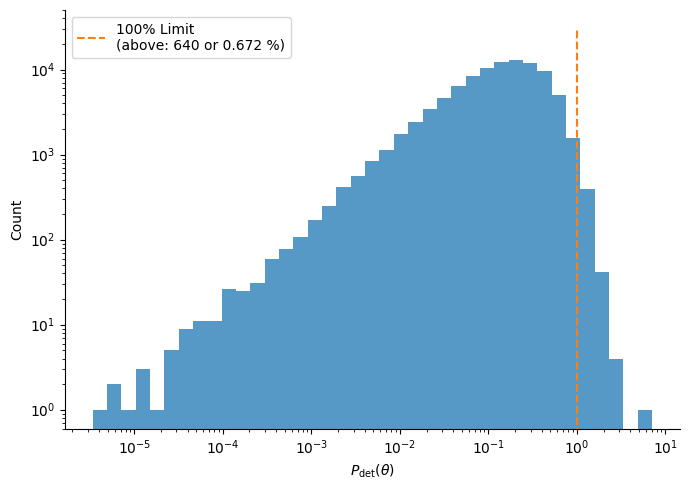

In [41]:
bins = np.logspace(
    np.log10(p_det.min()),
    np.log10(p_det.max()),
    40
)

sns.displot(p_det, bins=bins, height = 5, aspect = 1.4)
plt.vlines(x = 1.0, ymin = 0, ymax = 3e4, color = "tab:orange", linestyle = "--", label = f"100% Limit\n(above: {np.sum(p_det > 1)} or {np.sum(p_det > 1)/len(p_det) * 100:.3f} %)")
plt.legend(loc = "upper left")
plt.xlabel(r"$P_\mathrm{det}(\theta)$")
# plt.title("Histogram of NF-Predicted Detection Probabilites")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
# plt.savefig("plots/NFRatio/PdetHistogram_wTitle.pdf")
# plt.savefig("plots/NFRatio/PdetHistogram_wTitle.png", dpi = 300)

plt.show()

In [42]:
import sys
sys.path.append("../pdet_learn/PdetEmulator/learn-p-det4/code/")

In [43]:
from draw_new_injections import *

In [44]:
sample_spin?

Signature: sample_spin(n_samples, min_s=0.0, max_s=1.0)
Docstring:
Samples from p(s) ~ exp(-2s^2) on [min_s, max_s].
This corresponds to a Truncated Normal with mean=0, sigma=0.5.
File:      ~/Documents/pdet_learn/PdetEmulator/learn-p-det4/code/draw_new_injections.py
Type:      function

In [45]:
labels

Index(['m1_source', 'm2_source', 'redshift', 'a1', 'a2'], dtype='str')

In [46]:
# generate a batch samples
batch_size = 10000
# redshifts = sample_redshifts(batch_size, z_grid, dVdz_grid)
# m1, m2 = sample_masses(batch_size)
# a1, a2 = sample_spin(batch_size), sample_spin(batch_size)

new_samples_df = draw_new_injections_gwtc4(batch_size)

new_samples = jnp.stack([
    new_samples_df["m1_source"].to_numpy(),
    new_samples_df["m2_source"].to_numpy(),
    new_samples_df["redshift"].to_numpy(),
    new_samples_df["a1"].to_numpy(),
    new_samples_df["a2"].to_numpy(),
    # np.arccos(new_samples_df["cost1"]).to_numpy(),
    # np.arccos(new_samples_df["cost2"]).to_numpy(),
    # new_samples_df["phi1"].to_numpy(),
    # new_samples_df["phi2"].to_numpy(),
    # new_samples_df["right_ascension"].to_numpy(),
    # np.sin(new_samples_df["declination"].to_numpy()),
    # new_samples_df["polarization"].to_numpy(),
    # new_samples_df["cos_inclination"].to_numpy(),
]).T

In [47]:
new_samples_transformed = val_dataset.X_data.forward_transform(new_samples)
# new_samples_whitened = ut._apply_whitening(new_samples_transformed, X_data.mu, X_data.L)

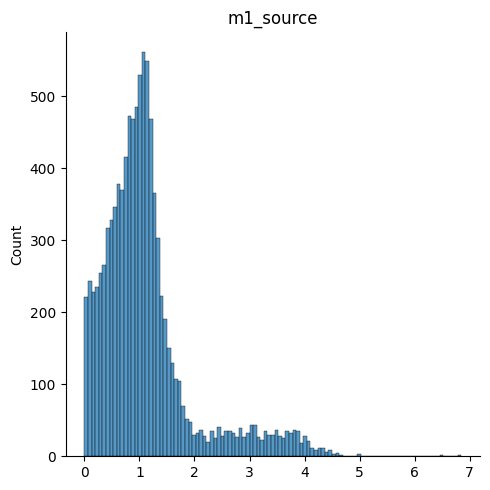

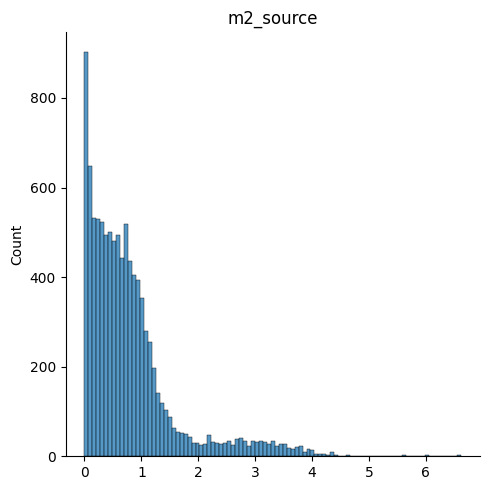

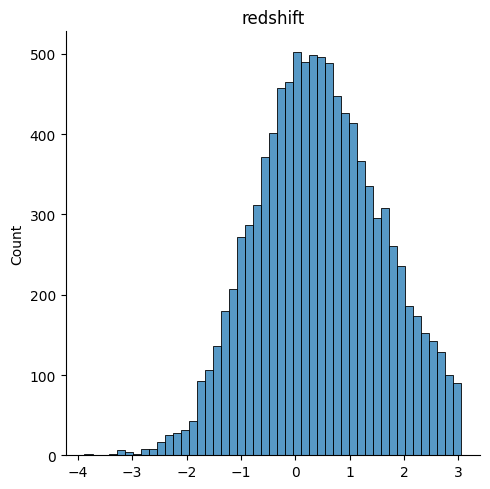

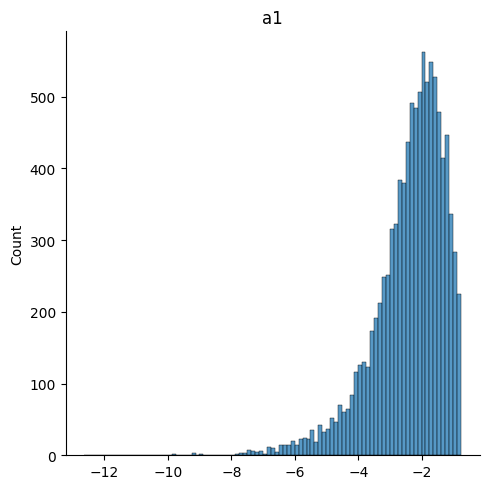

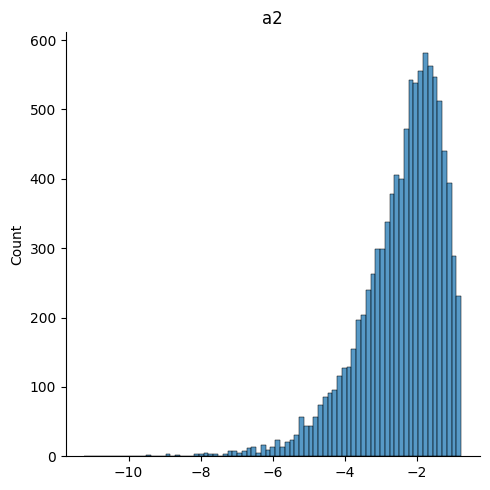

In [48]:
for i in range(new_samples_transformed.shape[1]):
    sns.displot(new_samples_transformed[:,i])
    plt.title(labels[i])
    plt.tight_layout()
    plt.show()

In [49]:
from functools import partial

import jax
import jax.numpy as jnp
from jax.scipy.special import erf, erfinv


COLS_13 = (
    "m1_source", "m2_source", "a1", "a2", "redshift",
    "cos_tilt1", "cos_tilt2", "phi1", "phi2",
    "right_ascension", "sin_declination", "polarization", "cos_inclination"
)


def _piecewise_m1_probs(exponents: jnp.array):
    # segments: (low, high, alpha)
    low  = jnp.array([1.0, 3.0, 8.0, 50.0, 200.0])
    high = jnp.array([3.0, 8.0, 50.0, 200.0, 1000.0])
    alpha = exponents # jnp.array([0.0, -4.0, -1.0, -4.0, -1.0])

    ratio = high / low

    # continuity heights at segment starts:
    # h0 = 1, h_i = prod_{k<i} (ratio_k ** alpha_k)
    inc = ratio ** alpha
    h_start = jnp.concatenate([jnp.array([1.0]), jnp.cumprod(inc)[:-1]])

    is_log = alpha == -1.0

    # segment areas
    log_area = h_start * low * jnp.log(ratio)
    denom = jnp.where(is_log, 1.0, alpha + 1.0)  # avoid divide-by-zero
    nonlog_area = (h_start * low / denom) * (ratio ** (alpha + 1.0) - 1.0)

    area = jnp.where(is_log, log_area, nonlog_area)
    probs = area / jnp.sum(area)

    return low, high, alpha, probs


def sample_masses_jax(key, n_samples: int, exponents: jnp.array):
    low, high, alpha, probs = _piecewise_m1_probs(exponents)

    key_seg, key_u, key_u2 = jax.random.split(key, 3)

    # choose segment index per sample (categorical over logits=log(probs)) [web:9]
    seg_idx = jax.random.categorical(key_seg, jnp.log(probs), shape=(n_samples,))

    u = jax.random.uniform(key_u, (n_samples,))
    u2 = jax.random.uniform(key_u2, (n_samples,))

    lo = low[seg_idx]
    hi = high[seg_idx]
    a = alpha[seg_idx]
    ratio = hi / lo
    is_log = a == -1.0

    # inverse-CDF per segment
    m1_log = lo * (ratio ** u)

    denom = jnp.where(is_log, 1.0, a + 1.0)  # safe
    expo = 1.0 / denom
    factor = ratio ** (a + 1.0) - 1.0
    term = factor * u + 1.0
    m1_nonlog = lo * (term ** expo)

    m1 = jnp.where(is_log, m1_log, m1_nonlog)

    # m2 | m1 with p(m2) ∝ m2 on [1, m1]
    m2 = jnp.sqrt(u2 * (m1 * m1 - 1.0) + 1.0)

    return m1, m2


def sample_spin_halfnormal_trunc_jax(key, n_samples: int, min_s=0.0, max_s=1.0, sigma=0.5):
    """
    Samples s >= 0 from a half-normal N(0, sigma) folded at 0, truncated to [min_s, max_s].
    For sigma=0.5 this is p(s) ∝ exp(-2 s^2) on [min_s, max_s].
    Uses inverse CDF via erf/erfinv. [web:7]
    """
    a = jnp.asarray(min_s)
    b = jnp.asarray(max_s)

    sqrt2sig = jnp.sqrt(2.0) * sigma
    Ea = erf(a / sqrt2sig)
    Eb = erf(b / sqrt2sig)

    u = jax.random.uniform(key, (n_samples,))
    t = u * (Eb - Ea) + Ea

    # avoid hitting exactly +/-1 due to float edge cases
    t = jnp.clip(t, -0.99999994, 0.99999994)

    return sqrt2sig * erfinv(t)


def sample_cos_tilts_jax(key, n_samples: int, p_aligned=0.3):
    key_mix, key_iso, key_align = jax.random.split(key, 3)

    r = jax.random.uniform(key_mix, (n_samples,))
    is_aligned = r < p_aligned

    cos_iso = jax.random.uniform(key_iso, (n_samples,), minval=-1.0, maxval=1.0)

    # aligned: pdf(x) ∝ (1+x)^3 on [-1,1], inverse CDF: x = 2*u^(1/4) - 1
    u = jax.random.uniform(key_align, (n_samples,))
    cos_align = 2.0 * (u ** 0.25) - 1.0

    return jnp.where(is_aligned, cos_align, cos_iso)


def sample_redshifts_from_grid_jax(key, n_samples: int, z_grid, dVdz_grid):
    """
    Samples z with PDF ∝ dVdz_grid on the provided grid using inverse CDF with linear interpolation. [web:1]
    Assumes z_grid is 1D and sorted ascending.
    """
    z_grid = jnp.asarray(z_grid)
    dVdz_grid = jnp.asarray(dVdz_grid)

    dz = z_grid[1:] - z_grid[:-1]
    areas = 0.5 * (dVdz_grid[:-1] + dVdz_grid[1:]) * dz
    cdf = jnp.concatenate([jnp.array([0.0], dtype=z_grid.dtype), jnp.cumsum(areas)])
    cdf = cdf / cdf[-1]

    u = jax.random.uniform(key, (n_samples,))
    # jnp.interp is JAX's numpy.interp implementation [web:1]
    return jnp.interp(u, cdf, z_grid)


@partial(jax.jit, static_argnames=("batch_size",))
def draw_new_injections_gwtc4_jax(key, batch_size: int, z_grid, dVdz_grid,
                                 spin_min=0.0, spin_max=1.0):
    """
    Returns: (batch_size, 13) array with columns COLS_13 in that order.
    """
    (k_masses, k_a1, k_a2, k_t1, k_t2,
     k_phi1, k_phi2, k_z, k_ra, k_sindec, k_pol, k_cosinc) = jax.random.split(key, 12)

    m1, m2 = sample_masses_jax(k_masses, batch_size, exponents = jnp.array([0, -4, -1, -4, -1]))

    a1 = sample_spin_halfnormal_trunc_jax(k_a1, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)
    a2 = sample_spin_halfnormal_trunc_jax(k_a2, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)

    cos_tilt1 = sample_cos_tilts_jax(k_t1, batch_size)
    cos_tilt2 = sample_cos_tilts_jax(k_t2, batch_size)

    phi1 = jax.random.uniform(k_phi1, (batch_size,), minval=0.0, maxval=1.0 * jnp.pi)
    phi2 = jax.random.uniform(k_phi2, (batch_size,), minval=0.0, maxval=1.0 * jnp.pi)

    redshift = sample_redshifts_from_grid_jax(k_z, batch_size, z_grid, dVdz_grid)

    right_ascension = jax.random.uniform(k_ra, (batch_size,), minval=0.0, maxval=2.0 * jnp.pi)
    sin_declination = jax.random.uniform(k_sindec, (batch_size,), minval=-1.0, maxval=1.0)
    polarization = jax.random.uniform(k_pol, (batch_size,), minval=0.0, maxval=jnp.pi)
    cos_inclination = jax.random.uniform(k_cosinc, (batch_size,), minval=-1.0, maxval=1.0)

    out = jnp.stack([
        m1, m2, a1, a2, redshift, cos_tilt1, cos_tilt2, phi1, phi2,
        right_ascension, sin_declination, polarization, cos_inclination
    ], axis=-1)

    return out

@partial(jax.jit, static_argnames=("batch_size",))
def draw_new_injections_gwtc4_jax_5D(key, batch_size: int, z_grid, dVdz_grid, exponents: jnp.array,
                                 spin_min=0.0, spin_max=1.0):
    """
    Returns: (batch_size, 13) array with columns COLS_5 in that order.
    """
    (k_masses, k_a1, k_a2, k_t1, k_t2,
     k_phi1, k_phi2, k_z, k_ra, k_sindec, k_pol, k_cosinc) = jax.random.split(key, 12)

    m1, m2 = sample_masses_jax(k_masses, batch_size, exponents = jnp.asarray(exponents))

    a_i = sample_spin_halfnormal_trunc_jax(k_a1, batch_size*2, min_s=spin_min, max_s=spin_max, sigma=0.5)
    a1 = a_i[::2]
    a2 = a_i[1::2]
    # a1 = sample_spin_halfnormal_trunc_jax(k_a1, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)
    # a2 = sample_spin_halfnormal_trunc_jax(k_a2, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)

    redshift = sample_redshifts_from_grid_jax(k_z, batch_size, z_grid, dVdz_grid)

    out = jnp.stack([
        m1, m2, redshift, a1, a2,
    ], axis=-1)

    return out

@partial(jax.jit, static_argnames=("batch_size",))
def draw_new_injections_gwtc4_jax_5D_tilts(key, batch_size: int, z_grid, dVdz_grid,
                                 spin_min=0.0, spin_max=1.0):
    """
    Returns: (batch_size, 13) array with columns COLS_5 in that order.
    """
    (k_masses, k_a1, k_a2, k_t1, k_t2,
     k_phi1, k_phi2, k_z, k_ra, k_sindec, k_pol, k_cosinc) = jax.random.split(key, 12)

    m1, m2 = sample_masses_jax(k_masses, batch_size, exponents = jnp.array([0, -4, -1, -4, -1]))

    # a1 = sample_spin_halfnormal_trunc_jax(k_a1, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)
    # a2 = sample_spin_halfnormal_trunc_jax(k_a2, batch_size, min_s=spin_min, max_s=spin_max, sigma=0.5)

    tilt1 = sample_tilts_jax(k_t1, batch_size)
    tilt2 = sample_tilts_jax(k_t2, batch_size)

    redshift = sample_redshifts_from_grid_jax(k_z, batch_size, z_grid, dVdz_grid)

    out = jnp.stack([
        m1, m2, redshift, t1, t2,
    ], axis=-1)

    return out

@partial(jax.jit, static_argnames=("batch_size",))
def draw_new_injections_gwtc4_jax_5D_phi(key, batch_size: int, z_grid, dVdz_grid,
                                 spin_min=0.0, spin_max=1.0):
    """
    Returns: (batch_size, 13) array with columns COLS_5 in that order.
    """
    (k_masses, k_a1, k_a2, k_t1, k_t2,
     k_phi1, k_phi2, k_z, k_ra, k_sindec, k_pol, k_cosinc) = jax.random.split(key, 12)

    m1, m2 = sample_masses_jax(k_masses, batch_size, exponents = jnp.array([0, -4, -1, -4, -1]))

    phi1 = jax.random.uniform(k_phi1, (batch_size,), minval=0.0, maxval=1.0 * jnp.pi)
    phi2 = jax.random.uniform(k_phi2, (batch_size,), minval=0.0, maxval=1.0 * jnp.pi)

    redshift = sample_redshifts_from_grid_jax(k_z, batch_size, z_grid, dVdz_grid)

    out = jnp.stack([
        m1, m2, redshift, phi1, phi2,
    ], axis=-1)

    return out

In [50]:
batch_size = 10000
# redshifts = sample_redshifts(batch_size, z_grid, dVdz_grid)
# m1, m2 = sample_masses(batch_size)
# a1, a2 = sample_spin(batch_size), sample_spin(batch_size)
standard_exponents = jnp.array([0, -4, -1, -4, -1])
new_samples_test = draw_new_injections_gwtc4_jax_5D(key, batch_size, z_grid, dVdz_grid, exponents = standard_exponents)

new_samples_test = jnp.stack([
    new_samples_test[:,0],
    new_samples_test[:,1],
    new_samples_test[:,2],
    new_samples_test[:,3],
    new_samples_test[:,4],
]).T

new_samples_test_transformed = val_dataset.X_data.forward_transform(new_samples_test)


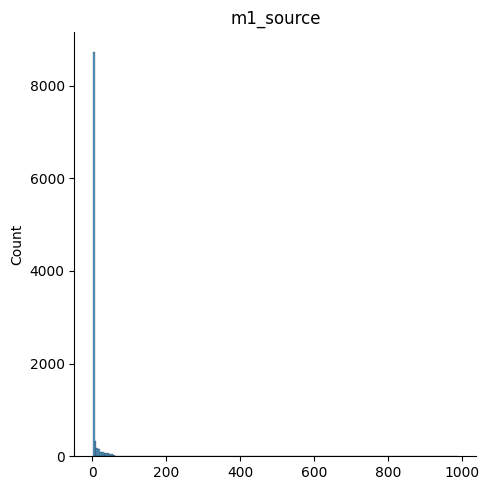

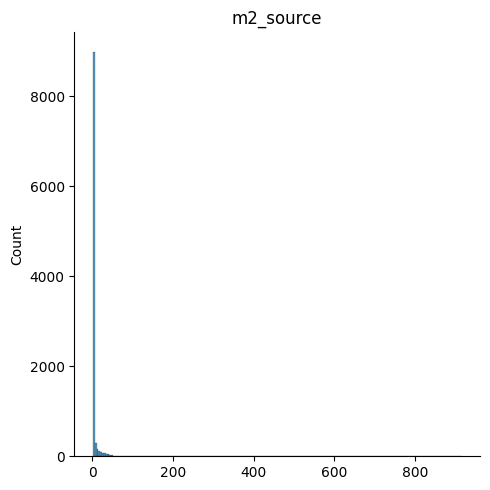

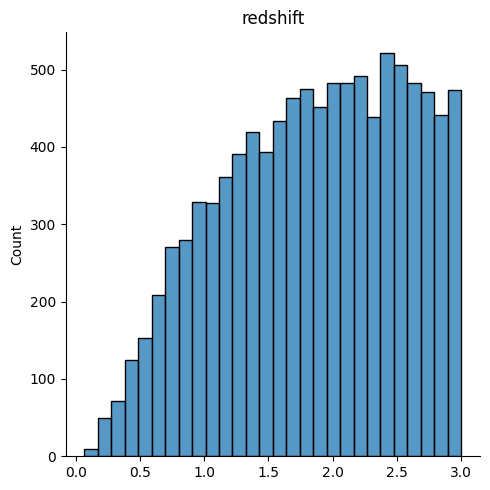

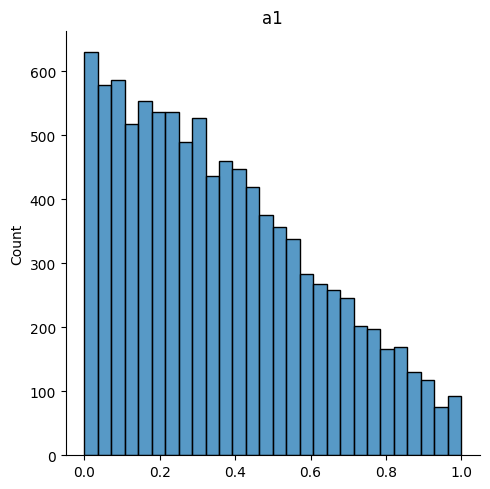

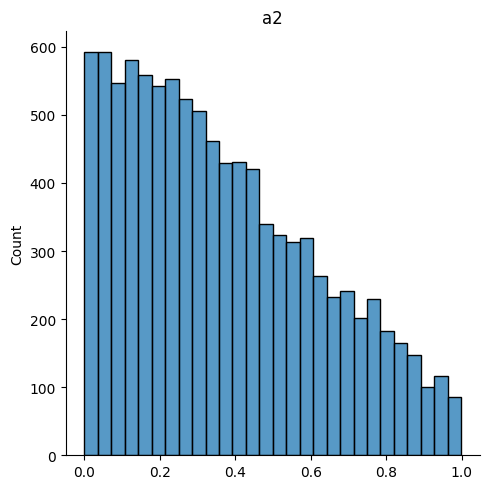

In [51]:
for i in range(new_samples_test.shape[1]):
    sns.displot(new_samples_test[:,i])
    plt.title(labels[i])
    plt.tight_layout()
    plt.show()

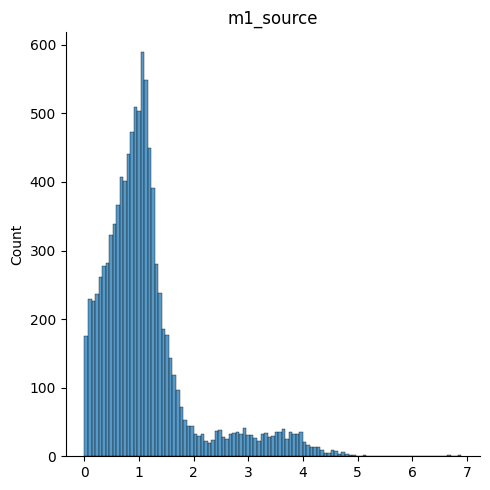

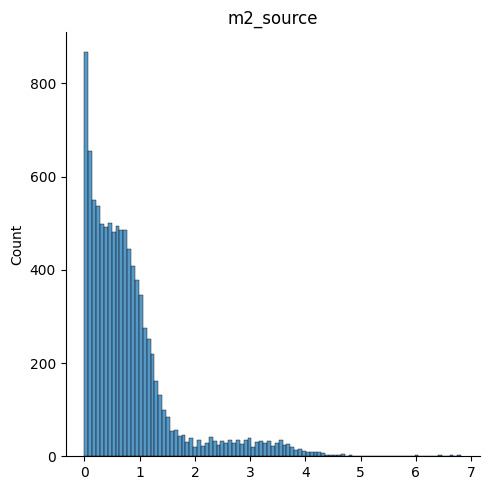

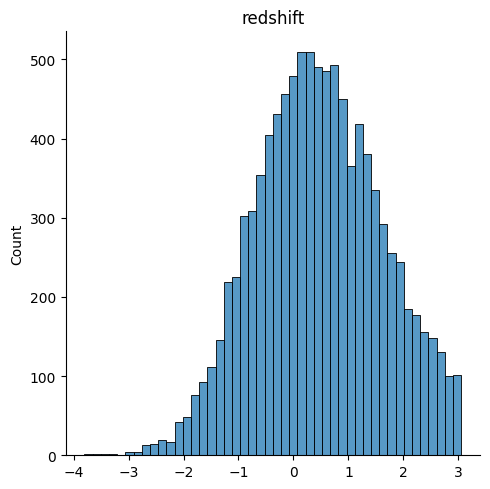

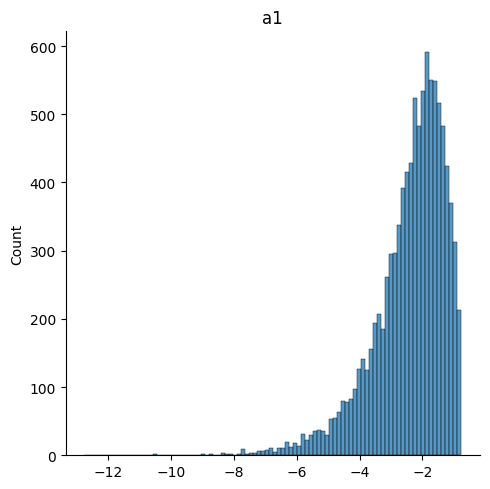

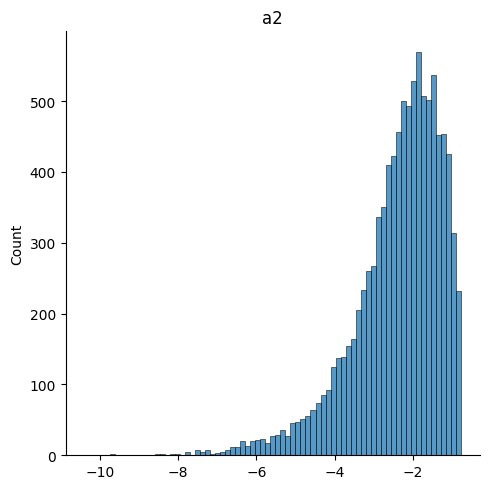

In [52]:
for i in range(new_samples_test_transformed.shape[1]):
    sns.displot(new_samples_test_transformed[:,i])
    plt.title(labels[i])
    plt.tight_layout()
    plt.show()

In [53]:
labels

Index(['m1_source', 'm2_source', 'redshift', 'a1', 'a2'], dtype='str')

In [54]:
log_jacobian_whitening, val_dataset.X_data.transformations

(Array(-1.68600995, dtype=float64),
 ['log', 'log', 'angle_pi', 'angle_pi', 'angle_pi'])

In [55]:
gen_N_found = len(val_dataset.X)
print(f"Need to generate {gen_N_found} samples")
batch_size = 10000000

key_val = 10
key = jax.random.key(key_val)

log_jacobian_whitening = jnp.sum(jnp.log(jnp.diag(dataset.X_data.L)))

found_samples = []
N_samples_found = 0
i = 0
p_dets_list = []
exponents_injections = jnp.array([0, -4, -1, -4, -1])
while N_samples_found < gen_N_found:
    key, subkey = jax.random.split(key)

    new_samples = draw_new_injections_gwtc4_jax_5D(subkey, batch_size=batch_size, z_grid=z_grid, dVdz_grid=dVdz_grid,exponents = standard_exponents)

    # is it the samples somehow?
    # new_samples = new_samples.at[:,3].set(new_samples[:,4])

    log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(new_samples.copy(), tuple(val_dataset.X_data.transformations))
    # print(log_jacobian_transformations)
    new_samples_transformed = dataset.X_data.forward_transform(new_samples.copy())
    # new_samples_whitened = ut._apply_whitening(new_samples_transformed, dataset.X_data.mu, dataset.X_data.L)
    
    # assert new_samples.shape == (batch_size, 13), f"wrong samples shape {new_samples.shape}"
    # assert new_samples_transformed.shape == (batch_size, 13), f"wrong samples shape {new_samples_transformed.shape}"
    # assert new_samples_whitened.shape == (batch_size, 13), f"wrong samples shape {new_samples_whitened.shape}"

    p_nf = jnp.exp(flow.log_prob(new_samples_transformed) + log_jacobian_transformations)
       
    pm1 = primary_mass_pdf_jax(new_samples[:,0], exponents = exponents_injections)
    pm2 = secondary_mass_pdf_jax(new_samples[:,1], new_samples[:,0])
    pz = redshift_pdf_jax(new_samples[:,2], z_grid, dVdz_grid)
    pa1 = spin_pdf_jax(new_samples[:,3])
    pa2 = spin_pdf_jax(new_samples[:,4])
    
    # pt1 = tilts_pdf_jax(new_samples[:,5])
    # pt2 = tilts_pdf_jax(new_samples[:,6])
    
    # pphi1 = jnp.ones_like(new_samples[:,5]) / (1*jnp.pi * jnp.abs(jnp.sin(jnp.arccos(new_samples[:,3])))) # uniform in [0, 2pi]
    # pphi2 = jnp.ones_like(new_samples[:,5]) / (1*jnp.pi * jnp.abs(jnp.sin(jnp.arccos(new_samples[:,4])))) # uniform in [0, 2pi]
    # pra = jnp.ones_like(new_samples[:,5]) / (2*jnp.pi) # uniform in [0, 2pi]
    # ppol = jnp.ones_like(new_samples[:,5]) / jnp.pi # uniform in [0, pi]
    # pdec = 1 / 2 # uniform in sin(delta) [-1, 1]
    # pinc = 1 / 2 # uniform in cos(inc) [-1, 1]
    
    p_inj = pm1*pm2*pz*pa1*pa2 # *pt1*pt2*pphi1*pphi2*pra*ppol*pdec*pinc
    
    p_det_nonorm = p_nf / p_inj
    p_det = p_det_nonorm*det_efficiency

    p_det_clipped = jnp.clip(p_det,0,1)
    p_dets_list.append(p_det_clipped)
    n_clip = jnp.sum(p_det > 1)
    
    key_rn, subkey_rn = jax.random.split(key)
    random_numbers = jax.random.uniform(subkey_rn, shape=p_det.shape)
    
    detected = p_det_clipped > random_numbers

    found_samples.append(new_samples[detected, :])
    N_samples_found += jnp.sum(detected)

    print(N_samples_found, 100*n_clip/batch_size)
    i += 1

    # sns.displot(new_samples[:,2])
    # plt.show()
    # sns.displot(new_samples[:,3])
    # plt.show()

Need to generate 95282 samples
9558 0.00139
19304 0.0012
29128 0.00108
38838 0.00116
48581 0.00132
58250 0.00128
68009 0.00145
77600 0.00128
87309 0.00129
97191 0.00118


In [56]:
n_trials = i*batch_size
n_trials, N_samples_found/n_trials

(100000000, Array(0.00097191, dtype=float64))

In [57]:
p_dets = jnp.concat(p_dets_list)
p_dets.shape, p_dets.mean()  # mean is the correct estimator (see Callister paper IV.A.5)

((100000000,), Array(0.00096828, dtype=float64))

In [58]:
len(val_dataset)

95282

In [59]:
found_samples_arr = jnp.concat(found_samples)

key, subkey = jax.random.split(key)

N = found_samples_arr.shape[0]
indices = jax.random.choice(subkey, N, shape=(len(val_dataset.X),), replace=False)

found_samples_arr = found_samples_arr[indices]

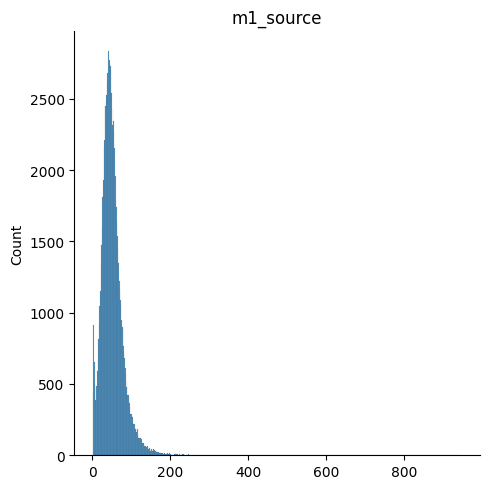

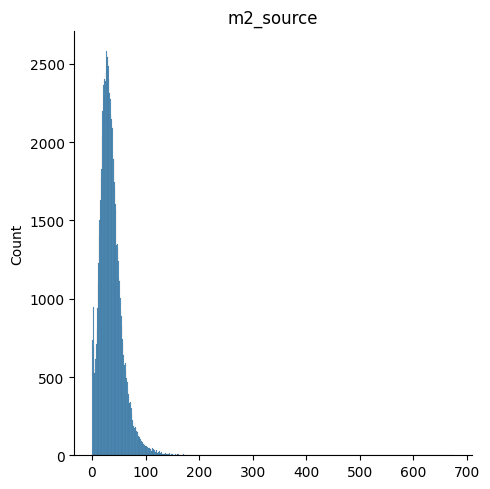

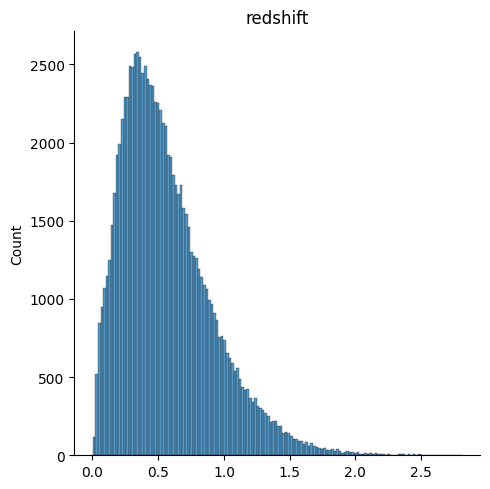

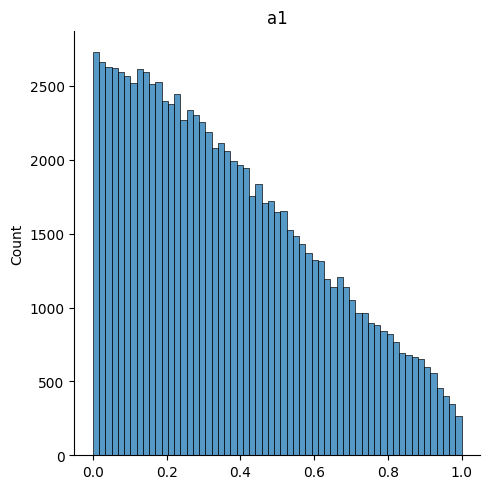

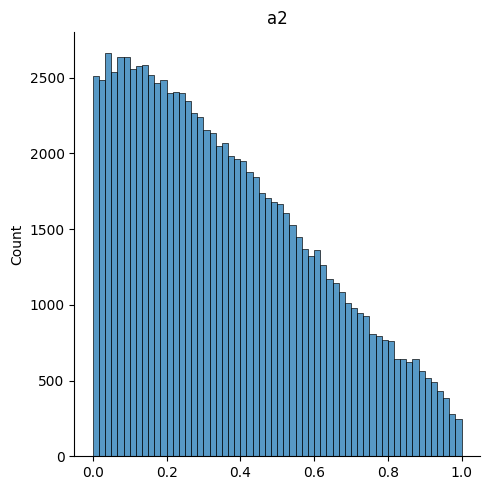

In [60]:
for i in range(found_samples_arr.shape[1]):
    sns.displot(found_samples_arr[:, i])
    plt.title(labels[i])
    plt.tight_layout()
    plt.show()

In [61]:
# Convert to pandas DataFrames for easy summary statistics
x_true, _ = dataset.to_original_space(val_dataset.X)
df_samples = pd.DataFrame(x_true, columns=labels)
df_detected = pd.DataFrame(found_samples_arr, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_detected.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_detected.corr())

--- Original Samples Summary Statistics ---


,m1_source,m2_source,redshift,a1,a2
count,95282.000000,95282.000000,95282.000000,95282.000000,9.528200e+04
mean,50.080085,37.586029,0.568443,0.374760,3.678616e-01
std,29.431068,22.886104,0.344806,0.255403,2.529274e-01
min,1.008008,1.001449,0.003710,0.000018,3.492302e-08
25%,32.781108,22.885709,0.310782,0.160970,1.566162e-01
50%,46.303323,34.170355,0.506799,0.334607,3.270391e-01
75%,61.074877,47.489573,0.765267,0.556690,5.457466e-01
max,693.507737,461.936645,2.909074,0.999952,9.999925e-01



--- Flow-Generated Samples Summary Statistics ---


,m1_source,m2_source,redshift,a1,a2
count,95282.000000,95282.000000,95282.000000,95282.000000,95282.000000
mean,51.195344,35.873531,0.564911,0.366842,0.362671
std,29.789144,21.665010,0.348524,0.252541,0.248582
min,1.047266,1.000938,0.002806,0.000018,0.000014
25%,33.069401,21.857359,0.308260,0.154674,0.154183
50%,46.758205,32.401185,0.497646,0.326050,0.322198
75%,63.389457,45.518084,0.753554,0.545528,0.536496
max,947.468643,675.763491,2.807233,0.999937,0.999766



--- Original Samples Correlation Matrix ---


,m1_source,m2_source,redshift,a1,a2
m1_source,1.000000,0.875575,0.250717,0.021645,0.004553
m2_source,0.875575,1.000000,0.298049,0.009034,0.008835
redshift,0.250717,0.298049,1.000000,0.057161,0.027988
a1,0.021645,0.009034,0.057161,1.000000,0.003451
a2,0.004553,0.008835,0.027988,0.003451,1.000000



--- Flow-Generated Samples Correlation Matrix ---


,m1_source,m2_source,redshift,a1,a2
m1_source,1.000000,0.865399,0.310658,0.008521,0.036131
m2_source,0.865399,1.000000,0.360784,0.008130,0.031692
redshift,0.310658,0.360784,1.000000,0.043004,0.014955
a1,0.008521,0.008130,0.043004,1.000000,-0.004058
a2,0.036131,0.031692,0.014955,-0.004058,1.000000


In [62]:
print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")
dowsample = 1
p_values = []
for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(x_true[::dowsample, i]), found_samples_arr[::dowsample, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    p_values.append(p_value)
    if p_value < 0.01:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: m1_source
  KS Statistic: 0.0285
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: m2_source
  KS Statistic: 0.0411
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: redshift
  KS Statistic: 0.0128
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: a1
  KS Statistic: 0.0127
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: a2
  KS Statistic: 0.0091
  P-value: 0.0007
  -> Distributions are statistically significantly different (reject H0)


In [63]:
labels

Index(['m1_source', 'm2_source', 'redshift', 'a1', 'a2'], dtype='str')

In [64]:
theta_pre_transform = data_df[labels].copy().to_numpy()
log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(theta_pre_transform, tuple(X_data.transformations))

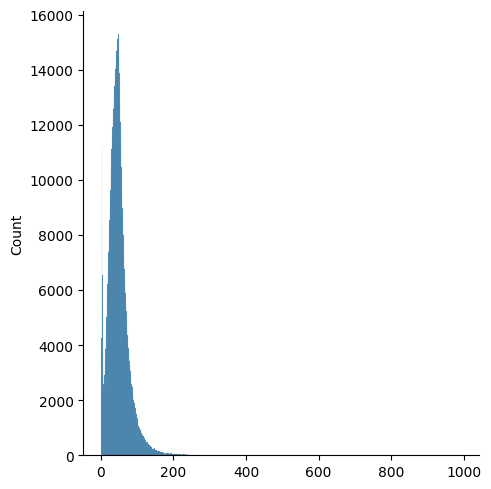

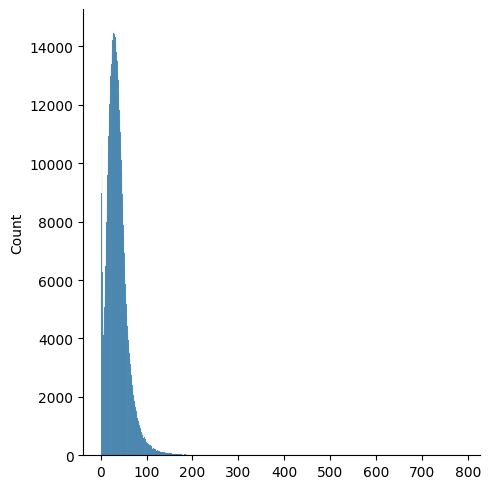

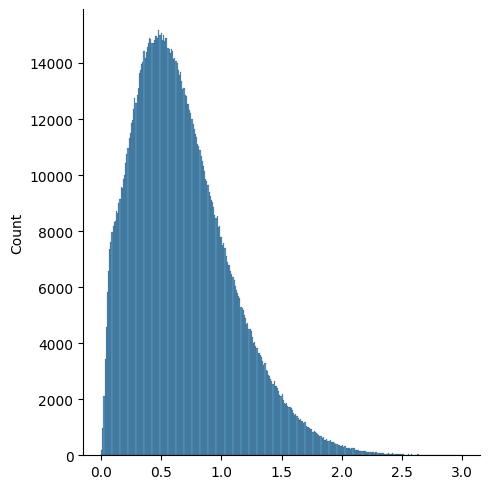

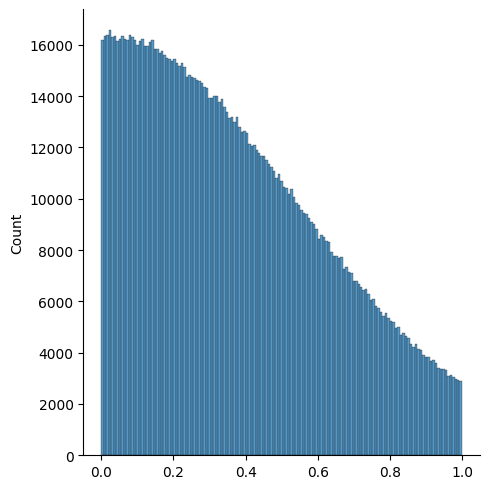

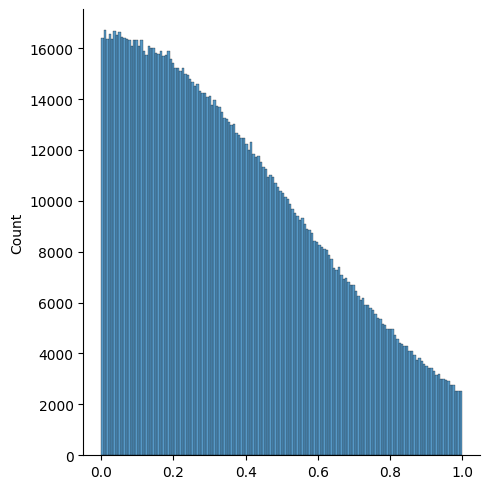

In [65]:
for data in theta_pre_transform.T:
    sns.displot(data)

In [66]:
# Reliability Diagram on all data

theta_pre_transform = data_df[labels].copy().to_numpy()
log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(theta_pre_transform, tuple(X_data.transformations))

theta_transformed = X_data.forward_transform(theta_pre_transform)
print(theta_transformed.shape)

p_nf_all = jnp.exp(flow.log_prob(theta_transformed) + log_jacobian_transformations)

pm1 = primary_mass_pdf(theta_pre_transform[:,0])
pm2 = secondary_mass_pdf(theta_pre_transform[:,1], theta_pre_transform[:,0])
pa1 = spin_pdf(theta_pre_transform[:,3])
pa2 = spin_pdf(theta_pre_transform[:,4])
pz = redshift_pdf(theta_pre_transform[:,2], z_grid, dVdz_grid)

p_inj_all = pm1*pm2*pa1*pa2*pz

p_det_all = det_efficiency * p_nf_all / p_inj_all
p_det_all_clipped = np.clip(p_det_all, 0,1)

(1499244, 5)


In [67]:
np.sum(p_det_all > 1), len(theta_pre_transform), # hmm there is around 600 events that are not detected but have p_det > 1...?

(Array(5422, dtype=int64), 1499244)

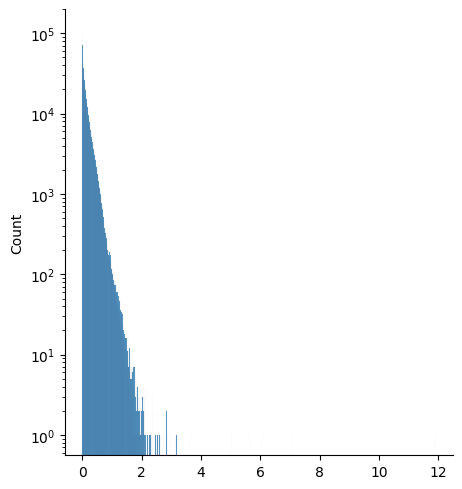

In [68]:
sns.displot(p_det_all)
plt.yscale("log")
# does that look good?

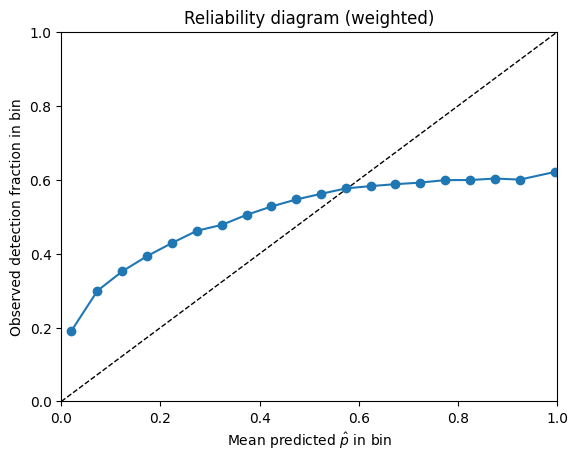

counts per bin: [551404 276024 180710 125659  90293  66945  50386  38234  29390  22324
  17040  13025   9587   6709   4752   3449   2726   2101   1689   6797]


In [69]:
n_bins = 20
# edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
cs, edges = np.histogram(p_det_all_clipped, bins = n_bins)
edges[0], edges[-1] = 0.0, 1.0  # nice endpoints

bin_id = np.digitize(p_det_all_clipped, edges[1:-1], right=True)  # 0..B-1

# f = sum w * D / sum w
# p = sum w * pdet / sum w

count = np.zeros(n_bins, dtype=int)
pbar = np.full(n_bins, np.nan)
fhat = np.full(n_bins, np.nan)

w = data_df["weights"]
D = data_df["detected"]

for b in range(n_bins):
    m = (bin_id == b)
    count[b] = m.sum()
    if count[b] == 0:
        continue
    wb = w[m]
    Z = wb.sum()
    pbar[b] = (wb * p_det_all_clipped[m]).sum() / Z
    fhat[b] = (wb * D[m]).sum() / Z

plt.plot([0,1],[0,1],'k--',lw=1)
plt.plot(pbar, fhat, marker='o')
plt.xlabel("Mean predicted $\\hat p$ in bin")
plt.ylabel("Observed detection fraction in bin")
plt.title("Reliability diagram (weighted)")
plt.ylim(0,1); plt.xlim(0,1)
plt.show()

print("counts per bin:", count)

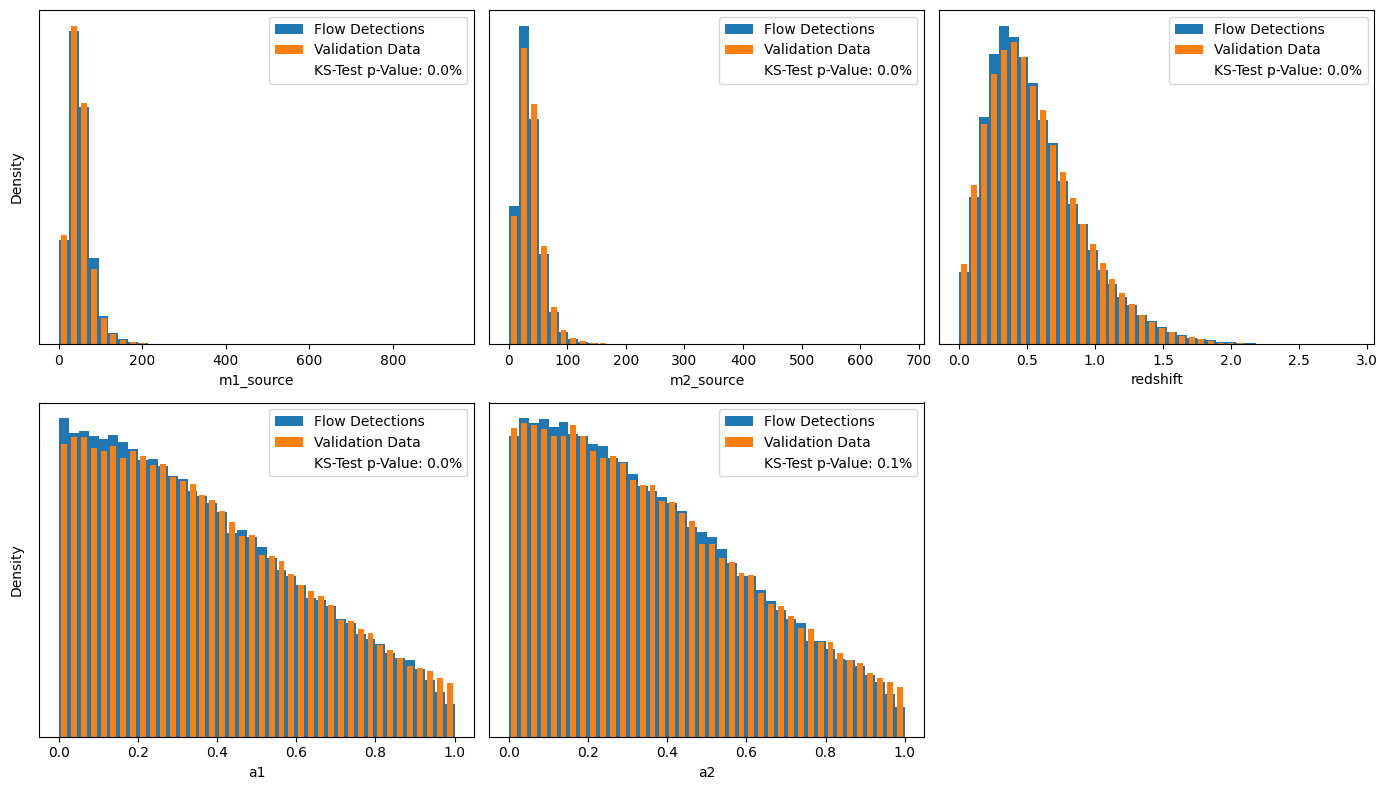

In [70]:
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (14,8))
axes = axes.flatten()

for i in range(found_samples_arr.shape[1]):
    data1, data2 = found_samples_arr[:, i], x_true[:, i]
    bins = np.histogram_bin_edges(np.concatenate([data1, data2]), bins=40)
    axes[i].hist(data1, bins = bins, alpha = 1, label = "Flow Detections", density = True)
    axes[i].hist(data2, bins = bins, alpha = 1, label = "Validation Data", rwidth=0.6, density = True)
    # plt.text(x = 0.8, y = 0.6, s = f"")
    ks_patch = mpatches.Patch(
        color='none',
        label=f"KS-Test p-Value: {100*p_values[i]:.1f}%"
    )

    # Collect handles and labels
    handles, labels_plot = axes[i].get_legend_handles_labels()
    handles.append(ks_patch)

    axes[i].legend(handles=handles, loc="best")

    if i%3 == 0:
        axes[i].set_ylabel("Density")
    axes[i].set_xlabel(labels[i])
    axes[i].tick_params(left = False)
    axes[i].set_yticklabels([])

axes[-1].axis("off")
# plt.title("Comparison of detected events in validation data and ")
plt.tight_layout()
plt.show()

In [71]:
n_test, n_exp = 10, 5
# test_exponents = np.random.uniform(low = -5, high = 0, size = (n_test, n_exp))
test_exponents = np.array(
    [
        [-0.5, -0.2, -1, -3.9, -2],
        [-1, -3, -2, -2, -3],
        [0.1, -4.3, -0.7, -3.8, -1.1],
    ]
)
standard_exp = np.array([[0, -4, -1, -4, -1]])
test_exponents = np.concat([test_exponents, standard_exp], axis = 0)
test_exponents.shape

(4, 5)

In [72]:
p_m1_all_list = []
for exps in tqdm(test_exponents):
    exps = jnp.array(exps)
    p_m1_all_list.append(primary_mass_pdf_jax(jnp.array(data_df["m1_source"].to_numpy()), exponents = exps))

100%|██████████| 4/4 [00:00<00:00, 13.90it/s]


In [73]:
p_m1_all = np.array(p_m1_all_list)
p_m1_all.shape

(4, 1499244)

In [74]:
data_df

,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,cos_right_ascension,declination,polarization,cos_polarization,redshift,...,p_draw_tilt1,p_draw_tilt2,p_draw_z,weights,far_min,detected,cos_tilt1,cos_tilt2,1_cos_phi1,1_cos_phi2
0,87.680089,56.912638,4.007806,-0.002645,5.002674,0.286225,-0.254790,0.614705,0.816944,0.651001,...,0.474854,0.346536,0.196423,0.804290,inf,0,0.222660,0.919241,1.660866,1.722868
1,54.408109,49.680587,2.381053,-0.489065,0.409010,0.917515,-0.917783,0.058546,0.998287,0.421988,...,0.526096,0.406582,0.107224,0.804290,inf,0,0.575831,0.876912,3.073524,5.015559
2,51.668975,20.366343,2.690371,0.910738,5.263240,0.523413,-0.698737,2.663313,-0.887788,0.467684,...,0.279013,0.520946,0.125065,0.804290,inf,0,-0.616144,0.658126,7.508927,0.500225
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.760524,-0.599299,0.296581,0.956341,0.637607,...,0.402610,0.479261,0.191349,0.804290,inf,0,-0.100166,0.788309,0.604822,0.570792
4,40.381354,34.546820,3.611020,0.871280,2.204904,-0.592459,1.053326,2.647054,-0.880188,0.597428,...,0.453030,0.427712,0.175935,0.804290,inf,0,0.124223,0.012047,2.335341,0.527903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,0.770968,1.044990,0.352504,0.938511,0.338223,...,0.374526,0.200322,0.075638,1.130915,inf,0,-0.227340,-0.820504,1.572122,27.291391
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,0.909386,1.191597,0.822922,0.680082,1.334967,...,0.418726,0.333749,0.385890,1.130915,inf,0,-0.027931,-0.408005,0.592903,0.731906
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.803980,-0.948454,1.955454,-0.375242,0.768044,...,0.411084,0.327793,0.239008,1.130915,inf,0,0.872972,-0.433076,21.958851,0.607883
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.649142,0.470035,0.662202,0.788640,0.072109,...,0.249478,0.180438,0.004544,1.130915,inf,0,-0.705303,0.981128,0.502313,0.508230


In [75]:
p_draw_m1 = data_df["p_draw_m1"].to_numpy()
weights = data_df["weights"].to_numpy()
detected = data_df["detected"].to_numpy() == True

detection_efficiencies = np.array([np.sum(weights[detected] * p_m1[detected] / p_draw_m1[detected]) for p_m1 in p_m1_all]) / metadata["total_generated"]

In [76]:
detection_efficiencies, detection_efficiencies.min(), detection_efficiencies.max(), detection_efficiencies.mean(), detection_efficiencies.std(), detection_efficiencies.shape

(array([0.00709768, 0.00063359, 0.00145288, 0.00112459]),
 np.float64(0.000633585464872028),
 np.float64(0.007097675304729044),
 np.float64(0.0025771841649645045),
 np.float64(0.0026261420964722934),
 (4,))

In [77]:
gen_N_found = 100_000
print(f"Need to generate {gen_N_found} samples")
batch_size = 10000000

key_val = 110
key = jax.random.key(key_val)

nf_det_efficiencies = []
nf_det_efficiencies_numeric = []

test_limit = len(test_exponents)
standard_exp_jax = jnp.array(standard_exp[0])

for key_val, exponents_injections in tqdm(enumerate(test_exponents[:test_limit])):

    print(exponents_injections)
    
    N_samples_found = 0
    p_dets_list = []
    batch_cnt = 0

    found_samples = []

    key_val = key_val
    key = jax.random.key(key_val)
    
    while N_samples_found < gen_N_found:
        key, subkey = jax.random.split(key)
    
        new_samples = draw_new_injections_gwtc4_jax_5D(subkey, batch_size=batch_size, z_grid=z_grid, dVdz_grid=dVdz_grid, exponents = exponents_injections)
    
        log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(new_samples.copy(), tuple(val_dataset.X_data.transformations))
    
        new_samples_transformed = dataset.X_data.forward_transform(new_samples.copy())
    
        p_nf = jnp.exp(flow.log_prob(new_samples_transformed) + log_jacobian_transformations)
           
        pm1 = primary_mass_pdf_jax(new_samples[:,0], exponents = standard_exp_jax)
        pm2 = secondary_mass_pdf_jax(new_samples[:,1], new_samples[:,0])
        pz = redshift_pdf_jax(new_samples[:,2], z_grid, dVdz_grid)
        pa1 = spin_pdf_jax(new_samples[:,3])
        pa2 = spin_pdf_jax(new_samples[:,4])
    
        p_inj = pm1*pm2*pz*pa1*pa2
        
        p_det_nonorm = p_nf / p_inj
        p_det = p_det_nonorm*det_efficiency
    
        p_det_clipped = jnp.clip(p_det,0,1)
        p_dets_list.append(p_det_clipped)

        key_rn, subkey_rn = jax.random.split(key)
        random_numbers = jax.random.uniform(subkey_rn, shape=p_det.shape)
        
        detected = p_det_clipped > random_numbers

        found_samples.append(new_samples[detected, :])

        N_samples_found += jnp.sum(detected)
        batch_cnt += 1
        
    p_dets = jnp.concat(p_dets_list)
    nf_det_efficiencies.append(float(p_dets.mean())) # mean is the correct estimator (see Callister paper IV.A.5)
    nf_det_efficiencies_numeric.append(float(N_samples_found / (batch_size*batch_cnt)))

Need to generate 100000 samples


0it [00:00, ?it/s]

[-0.5 -0.2 -1.  -3.9 -2. ]


1it [00:08,  8.77s/it]

[-1. -3. -2. -2. -3.]


2it [01:01, 34.88s/it]

[ 0.1 -4.3 -0.7 -3.8 -1.1]


3it [01:25, 29.84s/it]

[ 0. -4. -1. -4. -1.]


4it [01:58, 29.56s/it]


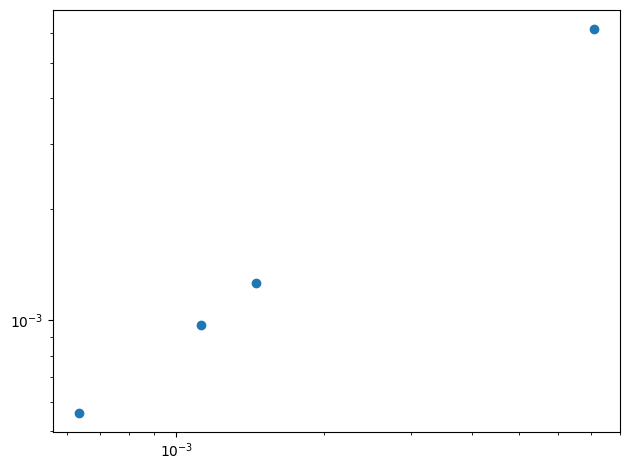

In [78]:
plt.scatter(detection_efficiencies[:test_limit], nf_det_efficiencies)
# plt.plot(nf_det_efficiencies, label = "NF Detection Efficiencies")
plt.yscale("log")
plt.xscale("log")
# plt.legend()
plt.tight_layout()
plt.show()

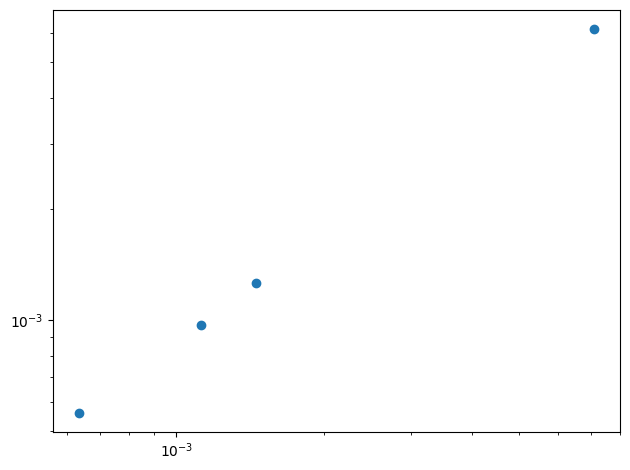

In [79]:
plt.scatter(detection_efficiencies[:test_limit], nf_det_efficiencies_numeric)
# plt.plot(nf_det_efficiencies, label = "NF Detection Efficiencies")
plt.yscale("log")
plt.xscale("log")
# plt.legend()
plt.tight_layout()
plt.show()

In [80]:
detection_efficiencies[:test_limit], nf_det_efficiencies, nf_det_efficiencies_numeric

(array([0.00709768, 0.00063359, 0.00145288, 0.00112459]),
 [0.006161481623484899,
  0.0005609441206294771,
  0.001257896964735107,
  0.0009690195780059335],
 [0.00614075, 0.0005604722222222222, 0.0012581, 0.0009666727272727273])

In [81]:
len(found_samples), len(found_samples[0])

(11, 9591)

In [82]:
found_samples_arr = jnp.concat(found_samples)
print(found_samples_arr.shape)

(106334, 5)


In [83]:
print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")
dowsample = 1
p_values = []
for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(x_true[::dowsample, i]), found_samples_arr[::dowsample, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    p_values.append(p_value)
    if p_value < 0.01:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

--- Kolmogorov-Smirnov Test for 1D Marginals ---
H0: The two samples are drawn from the same continuous distribution.
If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.

Parameter: m1_source
  KS Statistic: 0.0335
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: m2_source
  KS Statistic: 0.0369
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: redshift
  KS Statistic: 0.0108
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: a1
  KS Statistic: 0.0129
  P-value: 0.0000
  -> Distributions are statistically significantly different (reject H0)

Parameter: a2
  KS Statistic: 0.0066
  P-value: 0.0264
  -> Distributions are not statistically significantly different (fail to reject H0)


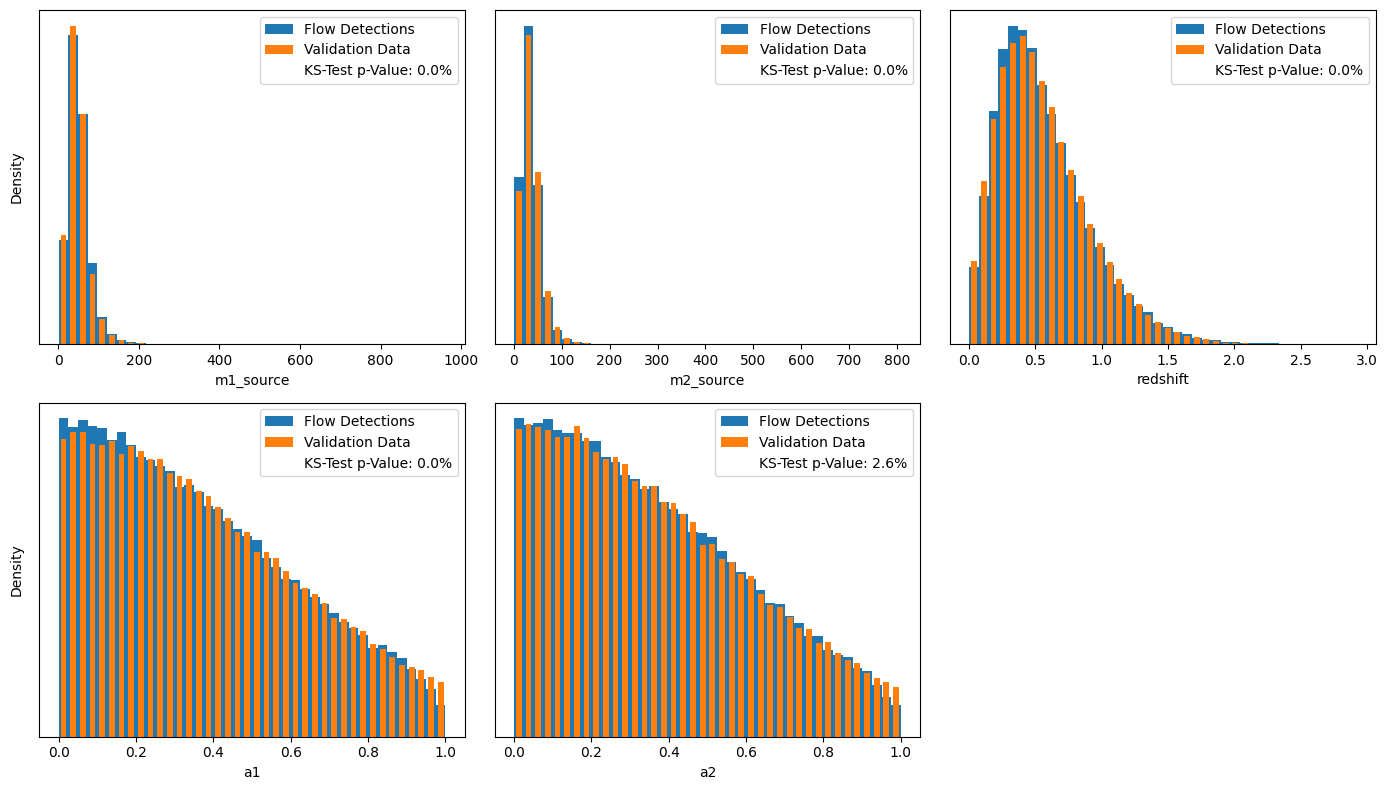

In [84]:
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (14,8))
axes = axes.flatten()

for i in range(found_samples_arr.shape[1]):
    data1, data2 = found_samples_arr[:, i], x_true[:, i]
    bins = np.histogram_bin_edges(np.concatenate([data1, data2]), bins=40)
    axes[i].hist(data1, bins = bins, alpha = 1, label = "Flow Detections", density = True)
    axes[i].hist(data2, bins = bins, alpha = 1, label = "Validation Data", rwidth=0.6, density = True)
    # plt.text(x = 0.8, y = 0.6, s = f"")
    ks_patch = mpatches.Patch(
        color='none',
        label=f"KS-Test p-Value: {100*p_values[i]:.1f}%"
    )

    # Collect handles and labels
    handles, labels_plot = axes[i].get_legend_handles_labels()
    handles.append(ks_patch)

    axes[i].legend(handles=handles, loc="best")

    if i%3 == 0:
        axes[i].set_ylabel("Density")
    axes[i].set_xlabel(labels[i])
    axes[i].tick_params(left = False)
    axes[i].set_yticklabels([])

axes[-1].axis("off")
# plt.title("Comparison of detected events in validation data and ")
plt.tight_layout()
plt.show()